# Snoozy Meditation Classifier

Binary classifier: **meditation vs. mind-wandering** from the OpenNeuro ds001787 probed EEG sessions.

Hardware target: **nRF54L15 + ADS1299-4 + BNO086**

Design choices:
- 10-second window before each probe onset
- 4 EEG channels selected from the research dataset to match the wearable electrode positions (Fp1, Fp2, AF7, AF8)
- Real-time-computable features: per-channel PSD bands, sub-bands, ratios, Hjorth params, spectral entropy, ZCR + cross-channel coherence and asymmetry
- Leave-One-Participant-Out (LOPO) cross-validation
- Export to ONNX for on-device inference

**Referencing note:** each ADS1299 input is wired as `FpX(+) / AFz(−)` so both channels share a common midline forehead reference. This gives the ADS1299's differential CMRR without collapsing to a single bipolar channel. The cross-channel asymmetry features (log Fp2_α − log Fp1_α, etc.) capture the same lateralization information that a hardware Fp1−Fp2 bipolar would, while keeping both channels available for per-channel features.

## Imports

In [1]:
import json
import warnings
import time
import math
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Optional deps for the Riemannian + LightGBM track
try:
    from pyriemann.estimation import Covariances
    from pyriemann.tangentspace import TangentSpace
    _PYRIEMANN_AVAILABLE = True
except Exception:
    Covariances = None
    TangentSpace = None
    _PYRIEMANN_AVAILABLE = False
    print("pyriemann not installed -- Riemannian track will be skipped. `pip install pyriemann` to enable.")

try:
    import lightgbm as lgb
    _LGBM_AVAILABLE = True
except Exception:
    lgb = None
    _LGBM_AVAILABLE = False
    print("lightgbm not installed -- LightGBM track will be skipped. `pip install lightgbm` to enable.")

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")


## Configuration

In [2]:
DATA_ROOT = Path("dataset/ds001787")
ARTIFACTS_DIR = Path("artifacts")

# --- EEG window ---
CONTEXT_SEC  = 10.0  # pre-probe context: total duration to extract sliding windows from
WINDOW_SEC   = 5.0   # feature window length (each sliding window)
STEP_SEC     = 1.0   # step between consecutive windows -> 6 windows per probe
N_SUBWINDOWS = 5     # split each window into N chunks for intra-window variability features
LOWCUT       = 0.5   # Hz  (bandpass pre-processing)
HIGHCUT      = 40.0  # Hz

# --- Channel selection ---
# BioSemi labelling: A1=Fp1, B2=Fp2, A2=AF7, B3=AF8, B1=Fpz
# ADS1299-4 differential inputs:
#   Ch1: (Fp1-Fp2)  Ch2: (AF7-AF8)  BIAS/REF: Fpz
# We compute (Fp1-Fp2)-Fpz and (AF7-AF8)-Fpz to match the hardware derivation.
PRIMARY_CHANNELS  = ["A1", "B2", "A2", "B3"]  # Fp1, Fp2, AF7, AF8 (needed for bipolars)
REFERENCE_CHANNEL = "B1"                        # Fpz -- subtracted from each bipolar pair
BIPOLAR_LABELS    = ["Fp1-Fp2", "AF7-AF8"]     # logical channel names for feature naming
N_CHANNELS_REQUIRED = 4                         # all 4 primaries must be present

# --- Label mapping ---
Q2_LABEL: Dict[int, str] = {2: "meditation", 4: "mind_wandering", 8: "mind_wandering"}
TARGET_LABELS = ["meditation", "mind_wandering"]

# --- Spectral bands ---
BANDS = {
    "delta":  (0.5,  4.0),
    "theta":  (4.0,  8.0),
    "alpha":  (8.0, 12.0),
    "sigma":  (12.0, 16.0),
    "beta":   (16.0, 30.0),
}
SUB_BANDS = {
    "theta1": (4.0,  6.0),
    "theta2": (6.0,  8.0),
    "alpha1": (8.0, 10.0),
    "alpha2": (10.0, 12.0),
}

USE_EEGNET   = True  # set True to run EEGNet LOPO (requires: braindecode, torch, skorch)
# Selector for the FINAL ONNX export. The LOPO sweep cell trains both
# eegnetv4 and shallow regardless; flip this to the winner before re-running
# the export cell.
EEGNET_ARCH  = "shallow"  # "shallow" (ShallowFBCSPNet) or "eegnet" (EEGNetv4)
RANDOM_STATE = 42

# --- Run toggles -------------------------------------------------------
# Flip these off when iterating on just the CNN: each LOPO loop is
# expensive (SVC: 24 folds * 9-cell GridSearchCV; Riemann+LGBM: 24 folds *
# 400 trees). Flip back on for a full baseline comparison.
RUN_SVC_LOPO     = False
RUN_RIEMANN_LOPO = False

# --- Dataset cache ----------------------------------------------------
# Both loaders now cache their output to DATASET_CACHE_DIR keyed on a
# hash of the preprocessing config; subsequent runs skip notch/bandpass/
# ASR entirely.
DATASET_CACHE_DIR = Path("dataset/_cache")
USE_DATASET_CACHE = True

# --- Artifact handling (forehead electrodes are heavily EOG-contaminated) ---
USE_NOTCH               = True
NOTCH_FREQS             = [50.0, 60.0]   # ds001787 is 50 Hz mains; deploy may see 60 Hz
USE_ASR                 = True            # Artifact Subspace Reconstruction (asrpy)
ASR_CUTOFF              = 20.0            # higher = more conservative (less aggressive)
ASR_FIT_SECONDS         = 30.0            # length of clean reference segment to fit ASR
USE_AMPLITUDE_REJECT    = True
ARTIFACT_PTP_UV         = 200.0           # peak-to-peak threshold per bipolar (uV)
ARTIFACT_PTP_UV_FALLBACK = 300.0          # softer threshold; auto-applied per subject if drop > 30%
PTP_FALLBACK_DROP_RATE  = 0.30            # threshold above which to promote a subject to the fallback PTP

# --- Training budget (LOPO sweep) -------------------------------------
MAX_EPOCHS         = 50
EARLY_STOP_PATIENCE = 10

_n_wins_per_probe = int((CONTEXT_SEC - WINDOW_SEC) / STEP_SEC) + 1
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"Sliding windows per probe: {_n_wins_per_probe}  "
      f"({CONTEXT_SEC:.0f}s context, {WINDOW_SEC:.0f}s window, {STEP_SEC}s step)")


DATA_ROOT exists: True
Sliding windows per probe: 6  (10s context, 5s window, 1.0s step)


## Feature Extraction

All features are computable in real-time from a single 5-second window on the nRF54L15 (Cortex-M33).

Feature layout (64 total):
- **Per channel × 2** (F7, F8): 5 band abs powers, 5 rel powers, 4 band ratios, 3 Hjorth, spectral entropy, ZCR, mean/std/rms, 4 sub-band powers, theta peak freq, alpha peak freq → **32 × 2 = 64** per channel
- Subtract cross-channel features from the count: **56 per-channel + 8 cross-channel = 64 total**

In [3]:
def _band_power(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    return float(np.sum(psd[mask])) if np.any(mask) else 0.0


def _peak_freq(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return (lo + hi) / 2.0
    return float(freqs[mask][np.argmax(psd[mask])])


def _spectral_entropy(psd: np.ndarray) -> float:
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log(p + 1e-12)))


def _spectral_edge_freq(psd: np.ndarray, freqs: np.ndarray, threshold: float = 0.95) -> float:
    cumsum = np.cumsum(psd)
    target = threshold * cumsum[-1]
    idx = int(np.searchsorted(cumsum, target))
    return float(freqs[min(idx, len(freqs) - 1)])


def _permutation_entropy(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    n = len(x)
    run_len = delay * (order - 1)
    if n <= run_len:
        return 0.0
    counts: dict = {}
    for i in range(n - run_len):
        pattern = tuple(np.argsort(x[i: i + run_len + 1: delay], kind="stable"))
        counts[pattern] = counts.get(pattern, 0) + 1
    total = sum(counts.values())
    probs = np.array(list(counts.values()), dtype=np.float64) / total
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


def _hjorth(x: np.ndarray) -> Tuple[float, float, float]:
    activity = float(np.var(x))
    d1 = np.diff(x)
    mobility = float(np.sqrt(np.var(d1) / (activity + 1e-12)))
    d2 = np.diff(d1)
    mob_d1 = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-12)))
    complexity = mob_d1 / (mobility + 1e-12)
    return activity, mobility, complexity


def _higuchi_fd(x: np.ndarray, kmax: int = 5) -> float:
    """Higuchi Fractal Dimension -- signal complexity measure (eeglib-inspired)."""
    n = len(x)
    lk = []
    for k in range(1, kmax + 1):
        lm_sum = 0.0
        for m in range(1, k + 1):
            idxs = np.arange(m - 1, n, k)
            if len(idxs) < 2:
                continue
            n_m = len(idxs) - 1
            lm_sum += np.sum(np.abs(np.diff(x[idxs]))) * (n - 1) / (k * n_m)
        lk.append(lm_sum / k)
    k_log  = np.log(np.arange(1, kmax + 1, dtype=np.float64))
    lk_log = np.log(np.array(lk, dtype=np.float64) + 1e-12)
    return float(np.polyfit(k_log, lk_log, 1)[0])


def channel_features(x: np.ndarray, fs: float) -> List[float]:
    """31 features from a single EEG channel."""
    x = x.astype(np.float64)
    nperseg = min(int(fs), len(x))
    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    total_power = float(np.sum(psd)) + 1e-12

    band_abs = {name: _band_power(psd, freqs, lo, hi) for name, (lo, hi) in BANDS.items()}
    band_rel = {name: v / total_power for name, v in band_abs.items()}

    feats: List[float] = []
    for name in BANDS:
        feats.append(band_abs[name])
    for name in BANDS:
        feats.append(band_rel[name])

    theta, alpha = band_abs["theta"], band_abs["alpha"]
    delta, beta  = band_abs["delta"],  band_abs["beta"]
    feats.append(theta / (alpha + 1e-12))
    feats.append(delta / (beta  + 1e-12))
    feats.append(alpha / (beta  + 1e-12))
    feats.append(theta / (beta  + 1e-12))

    feats.extend(_hjorth(x))
    feats.append(_spectral_entropy(psd))
    feats.append(float(np.mean(np.diff(np.signbit(x)) != 0)))
    feats.append(float(np.mean(x)))
    feats.append(float(np.std(x)))
    feats.append(float(np.sqrt(np.mean(x ** 2))))

    for lo, hi in SUB_BANDS.values():
        feats.append(_band_power(psd, freqs, lo, hi))

    feats.append(_peak_freq(psd, freqs, *BANDS["theta"]))
    feats.append(_peak_freq(psd, freqs, *BANDS["alpha"]))

    feats.append(_spectral_edge_freq(psd, freqs, 0.95))     # SEF95
    feats.append(_permutation_entropy(x, order=3, delay=1)) # PE
    feats.append(_higuchi_fd(x))                            # HFD

    return feats  # 5+5+4+3+1+1+3+4+2+2+1 = 31


def subwindow_features(x: np.ndarray, fs: float) -> List[float]:
    """7 intra-window variability features from a single channel."""
    x = x.astype(np.float64)
    n = len(x)
    chunk_size = n // N_SUBWINDOWS

    bp = np.zeros((N_SUBWINDOWS, len(BANDS)))
    for wi in range(N_SUBWINDOWS):
        chunk = x[wi * chunk_size: (wi + 1) * chunk_size]
        nperseg = min(int(fs), len(chunk))
        freqs, psd = welch(chunk, fs=fs, nperseg=nperseg)
        for bi, (lo, hi) in enumerate(BANDS.values()):
            bp[wi, bi] = _band_power(psd, freqs, lo, hi)

    feats: List[float] = list(bp.std(axis=0))

    t = np.arange(N_SUBWINDOWS, dtype=np.float64)
    feats.append(float(np.polyfit(t, bp[:, 1], 1)[0]))  # theta slope
    feats.append(float(np.polyfit(t, bp[:, 2], 1)[0]))  # alpha slope

    return feats  # 7 features


def cross_channel_features(eeg: np.ndarray, fs: float) -> List[float]:
    """5 features per channel pair: 1 corr + 4 log-asymmetry."""
    n_ch    = eeg.shape[0]
    nperseg = min(int(fs), eeg.shape[1])
    feats: List[float] = []

    psds: List[np.ndarray] = []
    freqs_ref: np.ndarray  = None
    for i in range(n_ch):
        freqs_ref, psd = welch(eeg[i].astype(np.float64), fs=fs, nperseg=nperseg)
        psds.append(psd)

    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            ch_i = eeg[i].astype(np.float64)
            ch_j = eeg[j].astype(np.float64)

            corr = float(np.corrcoef(ch_i, ch_j)[0, 1])
            feats.append(corr if np.isfinite(corr) else 0.0)

            for band_name in ("alpha", "theta", "delta", "beta"):
                lo, hi = BANDS[band_name]
                p_i = _band_power(psds[i], freqs_ref, lo, hi)
                p_j = _band_power(psds[j], freqs_ref, lo, hi)
                feats.append(float(np.log(p_j + 1e-12) - np.log(p_i + 1e-12)))

    return feats  # 5 * n_ch*(n_ch-1)//2 pairs


def extract_features(eeg: np.ndarray, fs: float) -> np.ndarray:
    """Full feature vector for an N-channel EEG epoch (shape: N x samples)."""
    feats: List[float] = []
    for ch in range(eeg.shape[0]):
        feats.extend(channel_features(eeg[ch], fs))
    feats.extend(cross_channel_features(eeg, fs))
    for ch in range(eeg.shape[0]):
        feats.extend(subwindow_features(eeg[ch], fs))
    return np.asarray(feats, dtype=np.float32)


def feature_names(ch_names: Sequence[str]) -> List[str]:
    """Ordered list of feature names matching extract_features output."""
    names: List[str] = []
    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_abs")
        for band in BANDS:
            names.append(f"{ch}_{band}_rel")
        names += [f"{ch}_theta_alpha", f"{ch}_delta_beta", f"{ch}_alpha_beta", f"{ch}_theta_beta"]
        names += [f"{ch}_hjorth_act", f"{ch}_hjorth_mob", f"{ch}_hjorth_cplx"]
        names.append(f"{ch}_spec_entropy")
        names.append(f"{ch}_zcr")
        names += [f"{ch}_mean", f"{ch}_std", f"{ch}_rms"]
        for sub in SUB_BANDS:
            names.append(f"{ch}_{sub}_abs")
        names.append(f"{ch}_theta_peak_hz")
        names.append(f"{ch}_alpha_peak_hz")
        names.append(f"{ch}_sef95")
        names.append(f"{ch}_perm_entropy")
        names.append(f"{ch}_hfd")

    for i, chi in enumerate(ch_names):
        for j, chj in enumerate(ch_names):
            if j <= i:
                continue
            pair = f"{chi}_{chj}"
            names.append(f"corr_{pair}")
            names += [f"asym_alpha_{pair}", f"asym_theta_{pair}",
                      f"asym_delta_{pair}", f"asym_beta_{pair}"]

    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_std_sw")
        names.append(f"{ch}_theta_slope_sw")
        names.append(f"{ch}_alpha_slope_sw")

    return names


# Smoke-test -- 2 bipolar channels, 31 per-channel features
_n_ch    = len(BIPOLAR_LABELS)        # 2
_n_pairs = _n_ch * (_n_ch - 1) // 2  # 1
_n_sw    = 7
_expected = _n_ch * 31 + _n_pairs * 5 + _n_ch * _n_sw  # 62 + 5 + 14 = 81
_dummy_eeg   = np.random.randn(_n_ch, int(256 * WINDOW_SEC)).astype(np.float32)
_dummy_feats = extract_features(_dummy_eeg, fs=256.0)
_dummy_names = feature_names(BIPOLAR_LABELS)
print(f"Channels: {_n_ch}  -> {_n_ch*31} per-channel + {_n_pairs*5} cross-channel + {_n_ch*_n_sw} subwindow = {_expected} total")
print(f"Feature vector length : {len(_dummy_feats)}")
print(f"Feature names length  : {len(_dummy_names)}")
assert len(_dummy_feats) == len(_dummy_names) == _expected, \
    f"Feature count mismatch: feats={len(_dummy_feats)}, names={len(_dummy_names)}, expected={_expected}"
print("Feature extraction OK")

Channels: 2  -> 62 per-channel + 5 cross-channel + 14 subwindow = 81 total
Feature vector length : 81
Feature names length  : 81
Feature extraction OK


## Dataset Loading

Selects F7 and F8 from each recording. Falls back to the best-available frontal pair if either channel is missing.

Probe label extraction follows the Q2 convention: stimulus/128 → responses → Q2 is the second response value (2=meditation, 4/8=mind_wandering). Adapted from `med_model.py`.

In [4]:
# --- Artifact handling helpers ---
# Forehead electrodes (Fp1/Fp2/AF7/AF8) sit directly above the eyes, so blink
# amplitudes (~100-300 uV) dwarf cortical signal (~5-20 uV). Per-window z-score
# alone makes blinks look like signal. We layer three cheap defenses:
#   1. notch_filter  -> kills mains
#   2. asrpy.ASR     -> reconstructs short bursts from a clean reference segment
#   3. peak-to-peak  -> drops windows that are still pathological after ASR
try:
    import asrpy
    _ASRPY_AVAILABLE = True
except Exception:
    asrpy = None
    _ASRPY_AVAILABLE = False
    print("asrpy not installed -- ASR will be skipped. `pip install asrpy` to enable.")

# Per-subject window-rejection counts: { subject_id: [kept, dropped] }
_DROP_STATS: Dict[str, List[int]] = {}

# Per-subject chosen PTP threshold (in uV). Populated by load_raw_dataset's
# two-pass calibration so cache keys can disambiguate.
_SUBJECT_PTP_UV: Dict[str, float] = {}


def _apply_notch(raw: "mne.io.BaseRaw") -> "mne.io.BaseRaw":
    """Notch out mains. Skips frequencies >= Nyquist for the current sfreq."""
    if not USE_NOTCH:
        return raw
    sfreq = float(raw.info["sfreq"])
    freqs = [f for f in NOTCH_FREQS if f < sfreq / 2.0]
    if not freqs:
        return raw
    raw.notch_filter(freqs=freqs, verbose="ERROR")
    return raw


def _apply_asr(raw: "mne.io.BaseRaw") -> "mne.io.BaseRaw":
    """Fit ASR on the cleanest segment of the recording, transform in place.

    Falls back to identity if asrpy is missing or fitting fails (e.g. recording
    shorter than ASR_FIT_SECONDS, or covariance is singular for very short
    segments).
    """
    if not USE_ASR or not _ASRPY_AVAILABLE:
        return raw
    sfreq = float(raw.info["sfreq"])
    fit_n = int(round(ASR_FIT_SECONDS * sfreq))
    if raw.n_times < fit_n + int(sfreq):
        return raw  # too short to fit
    try:
        asr = asrpy.ASR(sfreq=sfreq, cutoff=ASR_CUTOFF)
        # asrpy.ASR.fit auto-selects clean windows internally given the full
        # recording; passing a slice would only constrain it further. Pass full
        # raw and let the calibrator pick.
        asr.fit(raw)
        cleaned = asr.transform(raw)
        return cleaned
    except Exception as exc:
        print(f"  ASR fit/transform failed ({type(exc).__name__}: {exc}); skipping ASR")
        return raw


def _segment_clean(seg_volts: np.ndarray, threshold_uv: float) -> bool:
    """True if every channel's peak-to-peak in the segment is below threshold.

    `seg_volts` is shape (n_channels, n_samples) in volts (MNE native unit).
    """
    if not USE_AMPLITUDE_REJECT:
        return True
    ptp = np.ptp(seg_volts, axis=-1).max()
    return ptp <= threshold_uv * 1e-6


def _record_drop(subject_id: str, kept: bool) -> None:
    s = _DROP_STATS.setdefault(subject_id, [0, 0])
    if kept:
        s[0] += 1
    else:
        s[1] += 1


def _reset_drop_stats() -> None:
    _DROP_STATS.clear()


def _print_drop_stats(label: str) -> None:
    if not _DROP_STATS:
        return
    print(f"\n[{label}] artifact-rejection drop rates:")
    bad = []
    for subj, (kept, dropped) in sorted(_DROP_STATS.items()):
        total = kept + dropped
        rate = dropped / total if total else 0.0
        thresh = _SUBJECT_PTP_UV.get(subj, ARTIFACT_PTP_UV)
        flag = " <-- HIGH" if rate > PTP_FALLBACK_DROP_RATE else ""
        print(f"  {subj}: kept={kept:5d}  dropped={dropped:4d}  rate={rate:5.1%}  "
              f"ptp={thresh:.0f}uV{flag}")
        if rate > PTP_FALLBACK_DROP_RATE:
            bad.append(subj)
    if bad:
        print(f"  WARNING: {len(bad)} subject(s) STILL > {PTP_FALLBACK_DROP_RATE:.0%} drop "
              f"after fallback. Consider raising ARTIFACT_PTP_UV_FALLBACK.")


def _pick_subject_ptp(segments_volts: List[np.ndarray],
                      primary_uv: float,
                      fallback_uv: float,
                      max_drop: float) -> float:
    """Pick PTP threshold for one subject: stay at `primary_uv` unless the
    primary drop rate exceeds `max_drop`, in which case promote to `fallback_uv`.

    Operates on already-built per-window segments (post-bipolar, pre-z-score).
    Returns the chosen threshold in uV."""
    if not segments_volts:
        return primary_uv
    drops = sum(1 for s in segments_volts if not _segment_clean(s, primary_uv))
    rate = drops / len(segments_volts)
    if rate > max_drop:
        return fallback_uv
    return primary_uv


# --- Dataset caching helpers ----------------------------------------------
import hashlib

_FEATURE_VERSION = 2  # bump if extract_features() changes


def _dataset_cache_key(kind: str, extra: Dict) -> str:
    """Hash relevant config + extras into a short hex string. Used to name
    cache files so a config change auto-invalidates the cache."""
    payload = {
        "kind":              kind,
        "data_root":         str(DATA_ROOT),
        "lowcut":            LOWCUT,
        "highcut":           HIGHCUT,
        "context_sec":       CONTEXT_SEC,
        "window_sec":        WINDOW_SEC,
        "step_sec":          STEP_SEC,
        "primary_channels":  PRIMARY_CHANNELS,
        "reference_channel": REFERENCE_CHANNEL,
        "use_notch":         USE_NOTCH,
        "notch_freqs":       list(NOTCH_FREQS),
        "use_asr":           USE_ASR,
        "asr_cutoff":        ASR_CUTOFF,
        "asr_fit_seconds":   ASR_FIT_SECONDS,
        "use_amp_reject":    USE_AMPLITUDE_REJECT,
        "ptp_uv":            ARTIFACT_PTP_UV,
        "ptp_uv_fallback":   ARTIFACT_PTP_UV_FALLBACK,
        "ptp_fallback_rate": PTP_FALLBACK_DROP_RATE,
        **extra,
    }
    blob = json.dumps(payload, sort_keys=True, default=str).encode()
    return hashlib.sha1(blob).hexdigest()[:12]


def _cache_path(kind: str, key: str) -> Path:
    DATASET_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    return DATASET_CACHE_DIR / f"{kind}_{key}.npz"



In [5]:
def _has_required_channels(raw: mne.io.BaseRaw) -> bool:
    available = set(raw.ch_names)
    return all(ch in available for ch in PRIMARY_CHANNELS + [REFERENCE_CHANNEL])


def _extract_probe_label(events_df: pd.DataFrame, probe_idx: int) -> Optional[str]:
    responses: List[int] = []
    for j in range(probe_idx + 1, len(events_df)):
        row = events_df.iloc[j]
        tt = str(row.get("trial_type", "")).strip().lower()
        val = row.get("value")
        if tt == "stimulus" and pd.notna(val) and int(val) == 128:
            break
        if tt == "response" and pd.notna(val) and int(val) in Q2_LABEL:
            responses.append(int(val))
        if len(responses) == 3:
            break
    if len(responses) < 2:
        return None
    return Q2_LABEL.get(responses[1])


def _find_recording_pairs(sub_dir: Path) -> List[Tuple[Path, Path]]:
    pairs: List[Tuple[Path, Path]] = []
    for ses_dir in sorted(sub_dir.glob("ses-*")):
        if not ses_dir.is_dir():
            continue
        eeg_dir = ses_dir / "eeg"
        if not eeg_dir.is_dir():
            continue
        for eeg_path in sorted(eeg_dir.iterdir()):
            if eeg_path.suffix.lower() not in {".edf", ".bdf", ".set", ".fif"}:
                continue
            if "task-meditation" not in eeg_path.name:
                continue
            if f"_eeg{eeg_path.suffix}" not in eeg_path.name:
                continue
            events_path = eeg_path.with_name(
                eeg_path.name.replace(f"_eeg{eeg_path.suffix}", "_events.tsv")
            )
            if events_path.exists():
                pairs.append((eeg_path, events_path))
    return pairs


def _read_raw(eeg_path: Path) -> mne.io.BaseRaw:
    readers = {".edf": mne.io.read_raw_edf, ".bdf": mne.io.read_raw_bdf,
               ".set": mne.io.read_raw_eeglab, ".fif": mne.io.read_raw_fif}
    fn = readers.get(eeg_path.suffix.lower())
    if fn is None:
        raise ValueError(f"Unsupported format: {eeg_path.suffix}")
    return fn(eeg_path, preload=True, verbose="ERROR")


def _oas_cov_2x2(x: np.ndarray) -> np.ndarray:
    """OAS-shrinkage sample covariance for shape (n_channels, n_samples).

    Shrinks the sample covariance toward a scaled identity (Chen et al. 2010);
    robust for low-channel-count, short-window estimates. Inlined so the loader
    has no pyriemann dependency.
    """
    n_ch, n_samp = x.shape
    xc = x - x.mean(axis=1, keepdims=True)
    s = (xc @ xc.T) / max(n_samp - 1, 1)
    tr_s = np.trace(s)
    tr_s2 = np.trace(s @ s)
    mu = tr_s / n_ch
    num = (1.0 - 2.0 / n_ch) * tr_s2 + tr_s ** 2
    den = (n_samp + 1.0 - 2.0 / n_ch) * (tr_s2 - (tr_s ** 2) / n_ch)
    rho = 1.0 if den <= 0 else min(num / den, 1.0)
    return (1.0 - rho) * s + rho * mu * np.eye(n_ch)


def load_dataset(
    ds_root: Path,
    context_sec: float = CONTEXT_SEC,
    window_sec: float = WINDOW_SEC,
    step_sec: float = STEP_SEC,
    max_subjects: Optional[int] = None,
    force_refresh: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str], float]:
    """Returns X, y, groups, X_cov, channel_names, sampling_freq.

    Caches the result to DATASET_CACHE_DIR keyed on the preprocessing config.
    Pass force_refresh=True to ignore an existing cache and recompute.
    """
    cache_extra = {
        "feature_version": _FEATURE_VERSION,
        "context_sec_arg": context_sec,
        "window_sec_arg":  window_sec,
        "step_sec_arg":    step_sec,
        "max_subjects":    max_subjects,
    }
    cache_key  = _dataset_cache_key("features", cache_extra)
    cache_file = _cache_path("features", cache_key)
    if USE_DATASET_CACHE and not force_refresh and cache_file.exists():
        d = np.load(cache_file, allow_pickle=False)
        print(f"  cache hit: {cache_file.name}  ({d['y'].shape[0]} probes)")
        return (d["X"], d["y"].astype(str), d["groups"].astype(str),
                d["X_cov"], list(d["channel_names"].astype(str)),
                float(d["fs"][()]))

    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_sfreq: Optional[float] = None
    all_X:      List[np.ndarray] = []
    all_y:      List[str]        = []
    all_groups: List[str]        = []
    all_cov:    List[np.ndarray] = []

    load_chs = PRIMARY_CHANNELS + [REFERENCE_CHANNEL]
    _reset_drop_stats()

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            print(f"  skip {sub_dir.name}: no meditation EEG pairs")
            continue

        subj_probes = 0
        for rec_idx, (eeg_path, events_path) in enumerate(pairs):
            try:
                raw = _read_raw(eeg_path)
            except Exception as exc:
                print(f"  skip {eeg_path.name}: {exc}")
                continue

            if not _has_required_channels(raw):
                print(f"  skip {eeg_path.name}: required channels {load_chs} not all present")
                continue

            raw.pick(load_chs)
            _apply_notch(raw)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")

            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            raw = _apply_asr(raw)

            context_samples = int(round(context_sec * sfreq))
            window_samples  = int(round(window_sec  * sfreq))
            step_samples    = int(round(step_sec    * sfreq))

            idx = {ch: raw.ch_names.index(ch) for ch in load_chs}

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception as exc:
                print(f"  skip {events_path.name}: {exc}")
                continue

            if not {"onset", "trial_type", "value"}.issubset(events_df.columns):
                print(f"  skip {events_path.name}: missing required columns")
                continue

            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue

                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue

                probe_sample  = int(round(float(row["onset"]) * sfreq))
                context_start = probe_sample - context_samples
                if context_start < 0 or probe_sample > raw.n_times:
                    continue

                data_ctx = raw.get_data(start=context_start, stop=probe_sample)
                fpz_ctx  = data_ctx[idx[REFERENCE_CHANNEL]]

                probe_windows: List[np.ndarray]  = []
                probe_segments: List[np.ndarray] = []
                win_offset = 0
                while win_offset + window_samples <= context_samples:
                    seg = data_ctx[:, win_offset: win_offset + window_samples]
                    fpz = fpz_ctx[win_offset: win_offset + window_samples]
                    segment = np.stack([
                        seg[idx["A1"]] - seg[idx["B2"]] - fpz,
                        seg[idx["A2"]] - seg[idx["B3"]] - fpz,
                    ]).astype(np.float32)
                    is_clean = _segment_clean(segment, ARTIFACT_PTP_UV)
                    _record_drop(sub_dir.name, kept=is_clean)
                    if is_clean:
                        probe_windows.append(extract_features(segment, fs=sfreq))
                        probe_segments.append(segment)
                    win_offset += step_samples

                if not probe_windows:
                    continue

                concat = np.concatenate(probe_segments, axis=1)
                cov = _oas_cov_2x2(concat)

                all_X.append(np.mean(probe_windows, axis=0).astype(np.float32))
                all_cov.append(cov.astype(np.float32))
                all_y.append(label)
                all_groups.append(sub_dir.name)
                subj_probes += 1

        print(f"  {sub_dir.name}: {subj_probes} probes")

    if not all_X:
        raise ValueError("No usable epochs found -- check DATA_ROOT and channel names")

    X      = np.vstack(all_X).astype(np.float32)
    y      = np.asarray(all_y)
    groups = np.asarray(all_groups)
    X_cov  = np.stack(all_cov).astype(np.float32)

    print(f"\nLoaded {len(y)} probes from {len(np.unique(groups))} subjects")
    print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")
    print(f"Channels: {BIPOLAR_LABELS}  |  fs: {canonical_sfreq} Hz")
    print(f"Per-probe covariance: {X_cov.shape}")
    _print_drop_stats("SVC loader")
    if USE_DATASET_CACHE:
        np.savez_compressed(
            cache_file,
            X=X, y=y, groups=groups, X_cov=X_cov,
            channel_names=np.asarray(BIPOLAR_LABELS),
            fs=np.asarray(canonical_sfreq),
        )
        print(f"  cache saved: {cache_file.name}")
    return X, y, groups, X_cov, list(BIPOLAR_LABELS), canonical_sfreq


In [6]:
print("Loading dataset...")
X, y, groups, X_cov, channel_names, fs = load_dataset(DATA_ROOT)

n_features = X.shape[1]
feat_names = feature_names(channel_names)
print(f"Feature matrix: {X.shape}  |  features: {n_features}")
print(f"Cov tensor:     {X_cov.shape}")
print(f"Subjects: {len(np.unique(groups))}  |  probes: {len(y)}")

Loading dataset...
  cache hit: features_79918970ea9f.npz  (790 probes)
Feature matrix: (790, 81)  |  features: 81
Cov tensor:     (790, 2, 2)
Subjects: 24  |  probes: 790


In [7]:
# Z-scoring removed -- SelectKBest + probe-level averaging reduce inter-subject variance.
X_sess = X.copy()
print(f"Feature matrix (no z-score): {X_sess.shape}")

Feature matrix (no z-score): (790, 81)


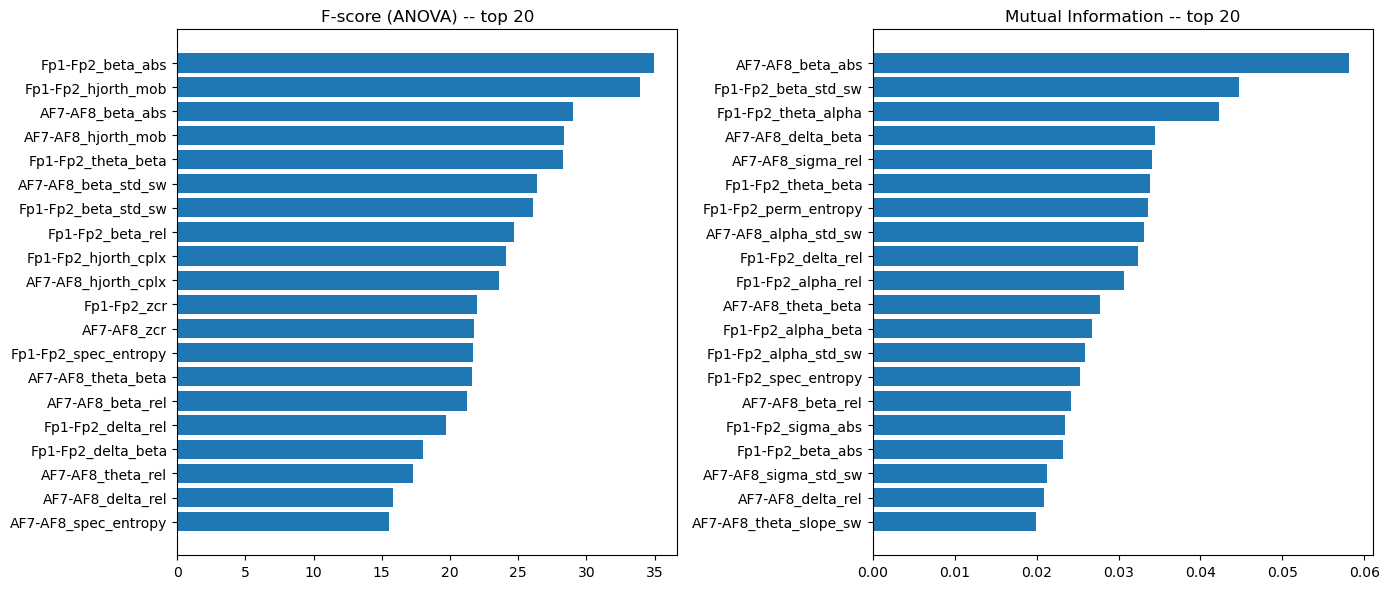

Top 10 by mutual information:
             feature   f_score  mi_score
    AF7-AF8_beta_abs 28.992394  0.058135
 Fp1-Fp2_beta_std_sw 26.064756  0.044759
 Fp1-Fp2_theta_alpha 13.767295  0.042215
  AF7-AF8_delta_beta  4.578188  0.034462
   AF7-AF8_sigma_rel  8.659737  0.034106
  Fp1-Fp2_theta_beta 28.279075  0.033852
Fp1-Fp2_perm_entropy  0.008304  0.033636
AF7-AF8_alpha_std_sw  7.304548  0.033137
   Fp1-Fp2_delta_rel 19.711080  0.032338
   Fp1-Fp2_alpha_rel  5.731654  0.030656


In [8]:
f_scores, _  = f_classif(X_sess, y)
mi_scores     = mutual_info_classif(X_sess, y, random_state=RANDOM_STATE)

ranking_df = pd.DataFrame({
    "feature":  feat_names,
    "f_score":  f_scores,
    "mi_score": mi_scores,
}).sort_values("mi_score", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in [
    (axes[0], "f_score",  "F-score (ANOVA) -- top 20"),
    (axes[1], "mi_score", "Mutual Information -- top 20"),
]:
    top = ranking_df.nlargest(20, col)
    ax.barh(top["feature"][::-1], top[col][::-1])
    ax.set_title(title)
plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "feature_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 by mutual information:")
print(ranking_df[["feature", "f_score", "mi_score"]].head(10).to_string(index=False))


## Model & LOPO Cross-Validation

Pipeline: `SimpleImputer → SVC`

The scaler is fit **only on training folds**, so no test-set leakage. LOPO uses all subjects as held-out test subjects in turn.

In [9]:
def make_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("select",  SelectKBest(f_classif, k=50)),
        ("clf",     SVC(kernel="rbf", C=1.0,
                        class_weight={"meditation": 1, "mind_wandering": 2},
                        probability=True, random_state=RANDOM_STATE)),
    ])

print("Pipeline: SimpleImputer -> StandardScaler -> SelectKBest(f_classif, k=50) -> SVC(rbf)")


Pipeline: SimpleImputer -> StandardScaler -> SelectKBest(f_classif, k=50) -> SVC(rbf)


In [10]:
# --- Item 2: Riemannian tangent-space + LightGBM, LOPO ---
# Adds 3 tangent-space features per probe (one TangentSpace fit per fold on
# training-fold covariances only) to the existing 81 hand-crafted features and
# trains LightGBM. Compare F1 to the SVC baseline cell above.

if not RUN_RIEMANN_LOPO:
    print("Riemann+LGBM LOPO skipped (RUN_RIEMANN_LOPO = False).")
elif not (_PYRIEMANN_AVAILABLE and _LGBM_AVAILABLE):
    print("Skipping Item 2: install `pyriemann` and `lightgbm` to enable.")
else:
    if "X_cov" not in globals():
        raise RuntimeError(
            "X_cov is missing -- re-run the SVC loader cell to refresh outputs "
            "(load_dataset now returns X, y, groups, X_cov, channel_names, fs)."
        )

    logo = LeaveOneGroupOut()
    rows = []
    y_int = np.where(y == "meditation", 0, 1)
    class_w = {0: 1.0, 1: 1.7}  # mind_wandering ~ 37.5% of probes
    y_true_all: List[int] = []
    y_pred_all: List[int] = []

    for fold_idx, (tr, te) in enumerate(logo.split(X, y_int, groups), start=1):
        held = groups[te][0]
        # Tangent-space (Riemannian) features -- fit on training fold only
        ts = TangentSpace(metric="riemann")
        ts.fit(X_cov[tr])
        ts_tr = ts.transform(X_cov[tr])      # (n_train, 3)
        ts_te = ts.transform(X_cov[te])      # (n_test,  3)

        Xtr = np.hstack([X[tr], ts_tr]).astype(np.float32)
        Xte = np.hstack([X[te], ts_te]).astype(np.float32)

        clf = lgb.LGBMClassifier(
            n_estimators=400,
            num_leaves=31,
            learning_rate=0.05,
            min_child_samples=20,
            reg_lambda=1.0,
            class_weight=class_w,
            random_state=RANDOM_STATE,
            verbose=-1,
        )
        clf.fit(Xtr, y_int[tr])
        pred = clf.predict(Xte)
        y_true_all.extend(y_int[te].tolist())
        y_pred_all.extend(pred.tolist())
        rows.append({
            "fold":         fold_idx,
            "held_out":     held,
            "n_probes":     int(len(te)),
            "balanced_acc": float(balanced_accuracy_score(y_int[te], pred)),
            "f1_macro":     float(f1_score(y_int[te], pred, average="macro", zero_division=0)),
            "rec_med":      float(recall_score(y_int[te], pred, pos_label=0, zero_division=0)),
            "rec_mw":       float(recall_score(y_int[te], pred, pos_label=1, zero_division=0)),
        })
        r = rows[-1]
        print(f"  Fold {fold_idx:2d} | {held} | probes={r['n_probes']:3d} | "
              f"bal_acc={r['balanced_acc']:.3f} | F1={r['f1_macro']:.3f} | "
              f"rec_med={r['rec_med']:.2f} | rec_mw={r['rec_mw']:.2f}")

    lgbm_df = pd.DataFrame(rows)
    print(f"\nRiemann+LGBM LOPO -- Macro F1: {lgbm_df['f1_macro'].mean():.3f}  "
          f"Bal Acc: {lgbm_df['balanced_acc'].mean():.3f}  "
          f"MW Recall: {lgbm_df['rec_mw'].mean():.3f}")
    print(classification_report(
        y_true_all, y_pred_all,
        labels=[0, 1],
        target_names=["meditation", "mind_wandering"],
        zero_division=0,
    ))


Riemann+LGBM LOPO skipped (RUN_RIEMANN_LOPO = False).


In [11]:
if not RUN_SVC_LOPO:
    print("SVC LOPO skipped (RUN_SVC_LOPO = False).")
else:
    from sklearn.model_selection import GridSearchCV, StratifiedKFold
    
    _PARAM_GRID = {
        "select__k": [30, 40, 50],
        "clf__C":    [0.1, 1.0, 10.0],
    }
    
    
    def run_lopo(
        X: np.ndarray,
        y: np.ndarray,
        groups: np.ndarray,
    ) -> Tuple[List[dict], List[str], List[str], List[float]]:
        logo = LeaveOneGroupOut()
        fold_results: List[dict]  = []
        y_true_all:   List[str]   = []
        y_pred_all:   List[str]   = []
        y_proba_all:  List[float] = []
    
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
        for fold_idx, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), start=1
        ):
            held_out = str(groups[test_idx][0])
    
            if len(np.unique(y[test_idx])) < len(TARGET_LABELS):
                print(f"  Fold {fold_idx:2d} | held-out: {held_out} | skipped (single-class test set)")
                continue
    
            gs = GridSearchCV(
                make_pipeline(),
                _PARAM_GRID,
                cv=inner_cv,
                scoring="balanced_accuracy",
                n_jobs=-1,
                refit=True,
            )
            gs.fit(X[train_idx], y[train_idx])
            model = gs.best_estimator_
    
            y_pred  = model.predict(X[test_idx])
            med_idx = list(model.classes_).index("meditation")
            y_proba = model.predict_proba(X[test_idx])[:, med_idx]
    
            fold_results.append({
                "fold":               fold_idx,
                "held_out":           held_out,
                "n_train":            int(len(train_idx)),
                "n_test":             int(len(test_idx)),
                "best_k":             int(gs.best_params_["select__k"]),
                "best_C":             float(gs.best_params_["clf__C"]),
                "accuracy":           float(accuracy_score(y[test_idx], y_pred)),
                "balanced_acc":       float(balanced_accuracy_score(y[test_idx], y_pred)),
                "f1_macro":           float(f1_score(y[test_idx], y_pred, average="macro", zero_division=0)),
                "recall_meditation":  float(recall_score(y[test_idx], y_pred, pos_label="meditation",     zero_division=0)),
                "recall_mw":          float(recall_score(y[test_idx], y_pred, pos_label="mind_wandering", zero_division=0)),
            })
            y_true_all.extend(y[test_idx].tolist())
            y_pred_all.extend(y_pred.tolist())
            y_proba_all.extend(y_proba.tolist())
    
            print(f"  Fold {fold_idx:2d} | held-out: {held_out} | "
                  f"k={gs.best_params_['select__k']} C={gs.best_params_['clf__C']:.1f} | "
                  f"bal_acc={fold_results[-1]['balanced_acc']:.3f} | "
                  f"F1={fold_results[-1]['f1_macro']:.3f} | "
                  f"rec_med={fold_results[-1]['recall_meditation']:.2f} | "
                  f"rec_mw={fold_results[-1]['recall_mw']:.2f}")
    
        return fold_results, y_true_all, y_pred_all, y_proba_all
    
    
    print("Running LOPO cross-validation (GridSearchCV: k in {30,40,50}, C in {0.1,1,10})...")
    fold_results, y_true, y_pred, y_proba = run_lopo(X_sess, y, groups)
    

SVC LOPO skipped (RUN_SVC_LOPO = False).


## Results

In [12]:
folds_df = pd.DataFrame(fold_results)

print("=" * 55)
print("LOPO Cross-Validation Summary")
print("=" * 55)
print(f"Subjects:          {len(folds_df)}")
print(f"Accuracy:          {folds_df['accuracy'].mean():.3f} ± {folds_df['accuracy'].std():.3f}")
print(f"Balanced accuracy: {folds_df['balanced_acc'].mean():.3f} ± {folds_df['balanced_acc'].std():.3f}")
print(f"F1 macro:          {folds_df['f1_macro'].mean():.3f} ± {folds_df['f1_macro'].std():.3f}")
print()
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))

folds_df

NameError: name 'fold_results' is not defined

Computing permutation importance (may take ~1 min)...


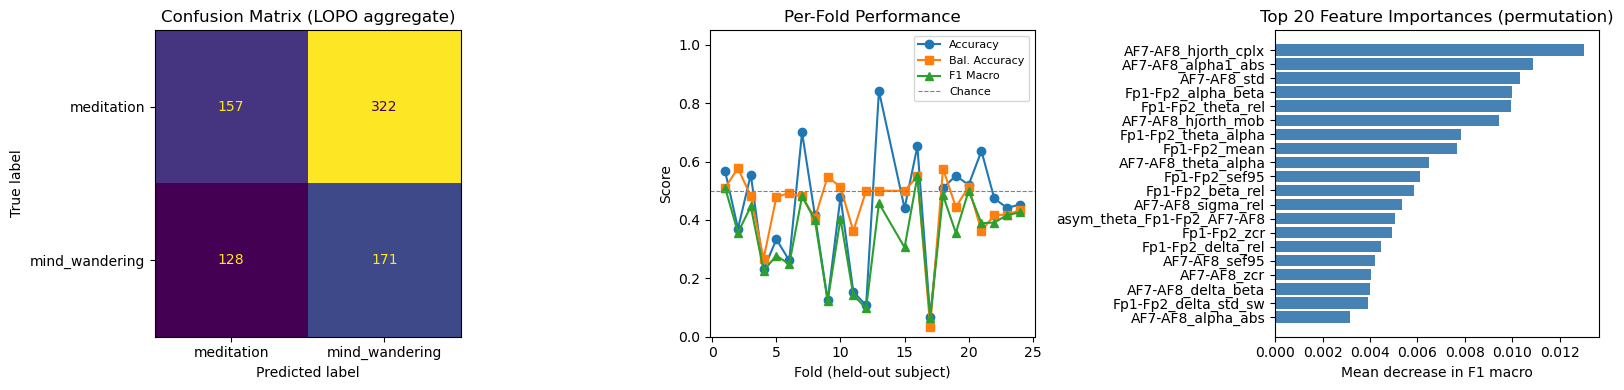

Saved lopo_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (LOPO aggregate)")

# Per-fold metrics
axes[1].plot(folds_df["fold"], folds_df["accuracy"],     "o-", label="Accuracy")
axes[1].plot(folds_df["fold"], folds_df["balanced_acc"], "s-", label="Bal. Accuracy")
axes[1].plot(folds_df["fold"], folds_df["f1_macro"],     "^-", label="F1 Macro")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
axes[1].set_xlabel("Fold (held-out subject)")
axes[1].set_ylabel("Score")
axes[1].set_title("Per-Fold Performance")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

# Feature importance via permutation (model-agnostic, works for SVC)
print("Computing permutation importance (may take ~1 min)...")
final_model = make_pipeline()
final_model.fit(X_sess, y)
perm = permutation_importance(
    final_model, X_sess, y,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro",
)
importances = perm.importances_mean
top_n  = 20
top_idx = np.argsort(importances)[::-1][:top_n]
axes[2].barh([feat_names[i] for i in top_idx[::-1]],
             importances[top_idx[::-1]], color="steelblue")
axes[2].set_title(f"Top {top_n} Feature Importances (permutation)")
axes[2].set_xlabel("Mean decrease in F1 macro")

plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "lopo_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lopo_results.png")

## Threshold Tuning

SVC with `probability=True` outputs calibrated probabilities. The default threshold of 0.5 often underpredicts the minority class. Sweeping the threshold using the LOPO-collected probabilities finds the value that maximises F1 macro without re-training.

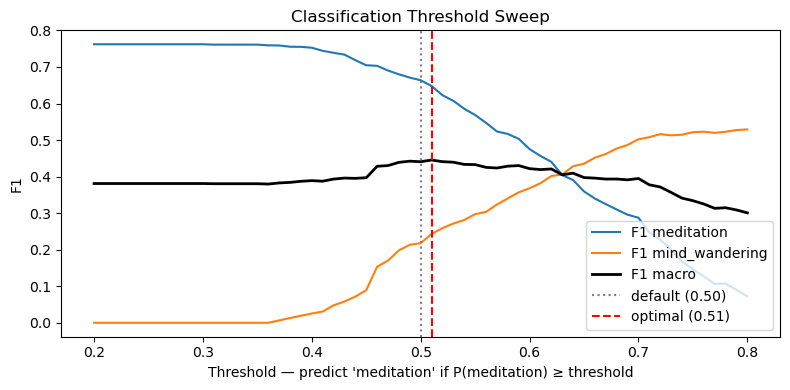

Default  threshold (0.50) → F1 macro: 0.441
Optimal  threshold (0.51) → F1 macro: 0.445  (+0.005)

--- Report at default threshold (0.50) ---
                precision    recall  f1-score   support

    meditation       0.55      0.33      0.41       479
mind_wandering       0.35      0.57      0.43       299

      accuracy                           0.42       778
     macro avg       0.45      0.45      0.42       778
  weighted avg       0.47      0.42      0.42       778

--- Report at optimal threshold (0.51) ---
                precision    recall  f1-score   support

    meditation       0.59      0.72      0.65       479
mind_wandering       0.31      0.20      0.24       299

      accuracy                           0.52       778
     macro avg       0.45      0.46      0.45       778
  weighted avg       0.48      0.52      0.49       778



In [ ]:
# Sweep classification threshold using LOPO-collected probabilities.
# Default threshold (0.5) may underpredict meditation — tuning balances per-class F1.
thresholds = np.linspace(0.2, 0.8, 61)
f1_med, f1_mw, f1_mac = [], [], []
y_proba_arr = np.array(y_proba)

for t in thresholds:
    y_pred_t = np.where(y_proba_arr >= t, "meditation", "mind_wandering")
    f1_med.append(f1_score(y_true, y_pred_t, pos_label="meditation",     zero_division=0))
    f1_mw.append( f1_score(y_true, y_pred_t, pos_label="mind_wandering", zero_division=0))
    f1_mac.append(f1_score(y_true, y_pred_t, average="macro",            zero_division=0))

best_t   = thresholds[np.argmax(f1_mac)]
best_f1  = max(f1_mac)
default_f1 = f1_mac[np.argmin(np.abs(thresholds - 0.5))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_med, label="F1 meditation")
ax.plot(thresholds, f1_mw,  label="F1 mind_wandering")
ax.plot(thresholds, f1_mac, label="F1 macro", linewidth=2, color="black")
ax.axvline(0.5,    color="gray", linestyle=":",  label="default (0.50)")
ax.axvline(best_t, color="red",  linestyle="--", label=f"optimal ({best_t:.2f})")
ax.set_xlabel("Threshold — predict 'meditation' if P(meditation) ≥ threshold")
ax.set_ylabel("F1")
ax.set_title("Classification Threshold Sweep")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "threshold_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default  threshold (0.50) → F1 macro: {default_f1:.3f}")
print(f"Optimal  threshold ({best_t:.2f}) → F1 macro: {best_f1:.3f}  (+{best_f1 - default_f1:.3f})")

# Classification report at optimal threshold
y_pred_tuned = np.where(y_proba_arr >= best_t, "meditation", "mind_wandering")
print(f"\n--- Report at default threshold (0.50) ---")
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))
print(f"--- Report at optimal threshold ({best_t:.2f}) ---")
print(classification_report(y_true, y_pred_tuned, target_names=TARGET_LABELS, zero_division=0))

## Real-Time Benchmark

Measure feature extraction and SVM inference time on this machine, then estimate latency on the nRF54L15 (Cortex-M33 @ 128 MHz) using known CMSIS-DSP cycle counts for `arm_rfft_fast_f32`.

In [ ]:
# Benchmark feature extraction to show real-time viability on nRF54L15 (Cortex-M33)
n_ch       = len(channel_names)
n_pairs    = n_ch * (n_ch - 1) // 2
sample_seg = np.random.randn(n_ch, int(fs * WINDOW_SEC)).astype(np.float32)

N = 200
t0 = time.perf_counter()
for _ in range(N):
    extract_features(sample_seg, fs)
pc_ms = (time.perf_counter() - t0) / N * 1000

# Time SVM inference separately
N_inf = 500
sample_feat = extract_features(sample_seg, fs).reshape(1, -1)
t0 = time.perf_counter()
for _ in range(N_inf):
    final_model.predict_proba(sample_feat)
infer_ms = (time.perf_counter() - t0) / N_inf * 1000

# nRF54L15 Cortex-M33 @ 128 MHz estimate with CMSIS-DSP
# arm_rfft_fast_f32(256) ≈ 1000 cycles ≈ 8 µs at 128 MHz
# Welch on WINDOW_SEC: ceil(2*WINDOW_SEC) segments per channel
n_segments   = math.ceil(2 * WINDOW_SEC)
fft_us       = n_segments * n_ch * 8    # per-channel Welch FFTs
scalar_us    = 200                       # band sums, Hjorth, ratios, ZCR, log-asymmetry, SEF95 (2 ch)
pe_us        = n_ch * 150               # permutation entropy O(n) per channel
svm_us       = 800                       # O(n_support × n_features)
m33_total_ms = (fft_us + scalar_us + pe_us + svm_us) / 1000

budget_ms = WINDOW_SEC * 1000
headroom  = budget_ms - m33_total_ms

print(f"Channels: {n_ch}  |  pairs: {n_pairs}  |  features: {len(feat_names)}")
print(f"Feature extraction  PC (Python):        {pc_ms:.1f} ms")
print(f"SVM inference       PC (Python):        {infer_ms:.2f} ms")
print()
print(f"M33 estimate (CMSIS-DSP arm_rfft_fast_f32):")
print(f"  FFT  ({n_segments} segs × {n_ch} ch × 8 µs):        {fft_us} µs")
print(f"  Scalar ops (bands, Hjorth, SEF95):      {scalar_us} µs")
print(f"  Permutation entropy ({n_ch} ch):          {pe_us} µs")
print(f"  SVM inference:                          {svm_us} µs")
print(f"  Total:                                  {m33_total_ms:.1f} ms")
print()
print(f"Window budget:  {budget_ms:.0f} ms")
print(f"Headroom:       {headroom:.0f} ms  ({headroom/budget_ms*100:.0f}% of budget remaining)")
print(f"Real-time viable: {'YES' if headroom > 0 else 'NO'}")

Channels: 2  |  pairs: 1  |  features: 81
Feature extraction  PC (Python):        23.7 ms
SVM inference       PC (Python):        1.38 ms

M33 estimate (CMSIS-DSP arm_rfft_fast_f32):
  FFT  (10 segs × 2 ch × 8 µs):        160 µs
  Scalar ops (bands, Hjorth, SEF95):      200 µs
  Permutation entropy (2 ch):          300 µs
  SVM inference:                          800 µs
  Total:                                  1.5 ms

Window budget:  5000 ms
Headroom:       4999 ms  (100% of budget remaining)
Real-time viable: YES


## EEGNet Mode (Optional -- braindecode)

Set `USE_EEGNET = True` in config to run. Install with: `pip install braindecode torch skorch`

In [7]:
def load_raw_dataset(
    ds_root: Path,
    window_sec: float = WINDOW_SEC,
    max_subjects: Optional[int] = None,
    force_refresh: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    """Per-window raw dataset for CNN training.

    Per-subject PTP fallback: each subject is first scored at ARTIFACT_PTP_UV;
    if their drop rate exceeds PTP_FALLBACK_DROP_RATE, the subject is rebuilt
    at ARTIFACT_PTP_UV_FALLBACK. Chosen thresholds are folded into the cache
    key.

    Caches the result to DATASET_CACHE_DIR keyed on the preprocessing config.
    Pass force_refresh=True to ignore the cache and recompute.
    """
    cache_extra = {
        "window_sec_arg": window_sec,
        "max_subjects":   max_subjects,
        # Calibration scheme matters for the cache key, but the resulting
        # per-subject choices are data-dependent and don't go in the key
        # (they're emitted to _SUBJECT_PTP_UV at runtime).
        "ptp_calibration": "per_subject_v1",
    }
    cache_key  = _dataset_cache_key("raw", cache_extra)
    cache_file = _cache_path("raw", cache_key)
    if USE_DATASET_CACHE and not force_refresh and cache_file.exists():
        d = np.load(cache_file, allow_pickle=False)
        print(f"  cache hit: {cache_file.name}  ({d['X_raw'].shape[0]} windows)")
        # Restore the per-subject threshold map if the cache stored it
        if "subject_ptp_keys" in d.files and "subject_ptp_vals" in d.files:
            _SUBJECT_PTP_UV.clear()
            for k, v in zip(d["subject_ptp_keys"].astype(str),
                            d["subject_ptp_vals"].astype(float)):
                _SUBJECT_PTP_UV[str(k)] = float(v)
        return (d["X_raw"], d["y_raw"].astype(str), d["g_raw"].astype(str),
                d["p_raw"].astype(str), float(d["fs_raw"][()]))

    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_sfreq: Optional[float] = None
    all_X:         List[np.ndarray] = []
    all_y:         List[str]        = []
    all_groups:    List[str]        = []
    all_probe_ids: List[str]        = []
    load_chs = PRIMARY_CHANNELS + [REFERENCE_CHANNEL]
    _reset_drop_stats()
    _SUBJECT_PTP_UV.clear()

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            continue

        # ---- Pass 1: build all (segment, label, probe_id) tuples for this
        #              subject pre-rejection so we can pick a PTP threshold.
        subj_segments: List[np.ndarray] = []
        subj_labels:   List[str]        = []
        subj_pids:     List[str]        = []
        for rec_idx, (eeg_path, events_path) in enumerate(pairs):
            try:
                raw = _read_raw(eeg_path)
            except Exception:
                continue
            if not _has_required_channels(raw):
                continue
            raw.pick(load_chs)
            _apply_notch(raw)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")
            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            raw = _apply_asr(raw)

            context_samples = int(round(CONTEXT_SEC * sfreq))
            window_samples  = int(round(window_sec  * sfreq))
            step_samples    = int(round(STEP_SEC    * sfreq))
            idx = {ch: raw.ch_names.index(ch) for ch in load_chs}

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception:
                continue

            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue
                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue
                probe_sample  = int(round(float(row["onset"]) * sfreq))
                context_start = probe_sample - context_samples
                if context_start < 0 or probe_sample > raw.n_times:
                    continue

                data_ctx = raw.get_data(start=context_start, stop=probe_sample)
                fpz_ctx  = data_ctx[idx[REFERENCE_CHANNEL]]
                probe_id = f"{sub_dir.name}_r{rec_idx}_p{i}"

                win_offset = 0
                while win_offset + window_samples <= context_samples:
                    seg = data_ctx[:, win_offset: win_offset + window_samples]
                    fpz = fpz_ctx[win_offset: win_offset + window_samples]
                    segment = np.stack([
                        seg[idx["A1"]] - seg[idx["B2"]] - fpz,
                        seg[idx["A2"]] - seg[idx["B3"]] - fpz,
                    ]).astype(np.float32)
                    subj_segments.append(segment)
                    subj_labels.append(label)
                    subj_pids.append(probe_id)
                    win_offset += step_samples

        if not subj_segments:
            continue

        # ---- Pick PTP threshold for this subject -----------------------
        ptp_uv = _pick_subject_ptp(
            subj_segments,
            ARTIFACT_PTP_UV, ARTIFACT_PTP_UV_FALLBACK,
            PTP_FALLBACK_DROP_RATE,
        )
        _SUBJECT_PTP_UV[sub_dir.name] = ptp_uv
        if ptp_uv != ARTIFACT_PTP_UV:
            print(f"  {sub_dir.name}: promoting PTP {ARTIFACT_PTP_UV:.0f} -> {ptp_uv:.0f} uV")

        # ---- Pass 2: apply rejection + z-score, accumulate -------------
        for segment, label, pid in zip(subj_segments, subj_labels, subj_pids):
            is_clean = _segment_clean(segment, ptp_uv)
            _record_drop(sub_dir.name, kept=is_clean)
            if not is_clean:
                continue
            seg_z = segment.copy()
            for ch in range(seg_z.shape[0]):
                s = seg_z[ch].std()
                if s > 1e-12:
                    seg_z[ch] = (seg_z[ch] - seg_z[ch].mean()) / s
            all_X.append(seg_z)
            all_y.append(label)
            all_groups.append(sub_dir.name)
            all_probe_ids.append(pid)

    X_raw = np.stack(all_X).astype(np.float32)  # (n_windows, 2, window_samples)
    y_raw = np.asarray(all_y)
    g_raw = np.asarray(all_groups)
    p_raw = np.asarray(all_probe_ids)
    n_probes = len(np.unique(p_raw))
    print(f"Raw dataset: {X_raw.shape}  |  windows={len(X_raw)}  probes={n_probes}  "
          f"classes={pd.Series(y_raw).value_counts().to_dict()}")
    _print_drop_stats("DL loader")
    if USE_DATASET_CACHE:
        np.savez_compressed(
            cache_file,
            X_raw=X_raw, y_raw=y_raw, g_raw=g_raw, p_raw=p_raw,
            fs_raw=np.asarray(canonical_sfreq),
            subject_ptp_keys=np.asarray(list(_SUBJECT_PTP_UV.keys())),
            subject_ptp_vals=np.asarray(list(_SUBJECT_PTP_UV.values()),
                                         dtype=np.float64),
        )
        print(f"  cache saved: {cache_file.name}")
    return X_raw, y_raw, g_raw, p_raw, canonical_sfreq


In [8]:
if not USE_EEGNET:
    print("EEGNet mode disabled. Set USE_EEGNET = True in config to run.")
    print("Install: pip install braindecode torch skorch")
else:
    try:
        import torch
        from braindecode.models import ShallowFBCSPNet, EEGNetv4
        from braindecode import EEGClassifier
        from braindecode.augmentation import (
            AugmentedDataLoader, GaussianNoise, SmoothTimeMask,
        )
        from skorch.callbacks import LRScheduler, EarlyStopping
        from skorch.helper import predefined_split
        from skorch.dataset import Dataset as SkorchDataset
        from sklearn.model_selection import train_test_split as tts
        from sklearn.utils.class_weight import compute_class_weight
    except ImportError:
        raise ImportError("Install braindecode + torch: pip install braindecode torch skorch")

    print("Loading raw per-window dataset for CNN...")
    X_raw, y_raw, g_raw, p_raw, fs_raw = load_raw_dataset(DATA_ROOT)

    label_map  = {"meditation": 0, "mind_wandering": 1}
    y_raw_int  = np.array([label_map[lb] for lb in y_raw])
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    n_times    = X_raw.shape[2]
    print(f"Device: {device_str}  |  windows: {len(X_raw)}  |  n_times: {n_times}")

    ARCHS = ["shallow"]

    def _build_module(arch: str):
        if arch == "eegnetv4":
            return EEGNetv4(
                n_chans=2, n_outputs=2,
                input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
                drop_prob=0.5,
            )
        elif arch == "shallow":
            return ShallowFBCSPNet(
                n_chans=2, n_outputs=2,
                input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
                n_filters_time=20, n_filters_spat=20, drop_prob=0.7,
            )
        raise ValueError(f"Unknown arch: {arch}")


    logo_eeg = LeaveOneGroupOut()
    # Per-arch result accumulators. probe_id is parallel to y_true/y_pred/proba_mw;
    # window_* streams retain the raw per-window outputs the stacker needs.
    sweep: Dict[str, dict] = {
        a: {"folds": [], "y_true": [], "y_pred": [],
             "proba_mw": [], "subject": [], "seq_idx": [],
             "probe_id": [],
             "window_proba_mw": [], "window_probe_id": [],
             "window_subject": []}
        for a in ARCHS
    }

    print(f"Running two-arch LOPO sweep ({ARCHS}) -- "
          f"max_epochs={MAX_EPOCHS}, patience={EARLY_STOP_PATIENCE}")
    for fold_idx, (train_idx, test_idx) in enumerate(
        logo_eeg.split(X_raw, y_raw_int, g_raw), start=1
    ):
        held_out = str(g_raw[test_idx][0])
        if len(np.unique(y_raw_int[test_idx])) < 2:
            print(f"  Fold {fold_idx:2d} | {held_out} | skipped (single class in test)")
            continue

        # Shared train/val split per fold so both arches see the same data
        train_sub, val_sub = tts(
            train_idx, test_size=0.15, stratify=y_raw_int[train_idx],
            random_state=RANDOM_STATE,
        )
        valid_ds = SkorchDataset(X_raw[val_sub], y_raw_int[val_sub])
        cw = compute_class_weight(
            "balanced", classes=np.array([0, 1]), y=y_raw_int[train_sub]
        )
        cw_tensor = torch.FloatTensor(cw).to(device_str)
        transforms = [
            GaussianNoise(probability=0.5, std=0.1, random_state=RANDOM_STATE),
            SmoothTimeMask(probability=0.5, mask_len_samples=int(0.25 * n_times),
                           random_state=RANDOM_STATE),
        ]

        for arch in ARCHS:
            clf = EEGClassifier(
                module=_build_module(arch),
                criterion=torch.nn.CrossEntropyLoss,
                criterion__weight=cw_tensor,
                optimizer=torch.optim.Adam,
                optimizer__lr=1e-3,
                optimizer__weight_decay=1e-4,
                batch_size=64,
                max_epochs=MAX_EPOCHS,
                iterator_train=AugmentedDataLoader,
                iterator_train__transforms=transforms,
                train_split=predefined_split(valid_ds),
                callbacks=[
                    ("lr_sched",   LRScheduler("CosineAnnealingLR", T_max=MAX_EPOCHS)),
                    ("early_stop", EarlyStopping(patience=EARLY_STOP_PATIENCE,
                                                  monitor="valid_loss")),
                ],
                device=device_str,
                verbose=0,
            )
            clf.fit(X_raw[train_sub], y_raw_int[train_sub])

            proba_win = clf.predict_proba(X_raw[test_idx])  # (n_test_windows, 2)
            test_probe_ids = p_raw[test_idx]
            probe_to_proba: Dict[str, list] = {}
            probe_to_label: Dict[str, int]  = {}
            for j, pid in enumerate(test_probe_ids):
                probe_to_proba.setdefault(pid, []).append(proba_win[j])
                probe_to_label[pid] = int(y_raw_int[test_idx][j])
            probe_ids_sorted = sorted(probe_to_proba.keys())
            probe_proba_mw = np.array([
                float(np.mean(probe_to_proba[pid], axis=0)[1])
                for pid in probe_ids_sorted
            ])
            probe_pred = (probe_proba_mw >= 0.5).astype(int)
            probe_true = np.array([probe_to_label[pid] for pid in probe_ids_sorted])

            r = {
                "fold":         fold_idx,
                "held_out":     held_out,
                "n_probes":     int(len(probe_true)),
                "accuracy":     float(accuracy_score(probe_true, probe_pred)),
                "balanced_acc": float(balanced_accuracy_score(probe_true, probe_pred)),
                "f1_macro":     float(f1_score(probe_true, probe_pred, average="macro", zero_division=0)),
                "recall_med":   float(recall_score(probe_true, probe_pred, pos_label=0, zero_division=0)),
                "recall_mw":    float(recall_score(probe_true, probe_pred, pos_label=1, zero_division=0)),
                "n_epochs":     int(len(clf.history)),
            }
            sweep[arch]["folds"].append(r)
            sweep[arch]["y_true"].extend(probe_true.tolist())
            sweep[arch]["y_pred"].extend(probe_pred.tolist())
            sweep[arch]["proba_mw"].extend(probe_proba_mw.tolist())
            sweep[arch]["subject"].extend([held_out] * len(probe_true))
            sweep[arch]["seq_idx"].extend(list(range(len(probe_true))))
            sweep[arch]["probe_id"].extend(probe_ids_sorted)
            # Per-window streams (P(mind_wandering) only -- 1 - this gives meditation)
            sweep[arch]["window_proba_mw"].extend(proba_win[:, 1].tolist())
            sweep[arch]["window_probe_id"].extend(test_probe_ids.tolist())
            sweep[arch]["window_subject"].extend([held_out] * len(test_probe_ids))
            print(f"  Fold {fold_idx:2d} | {held_out:9s} | {arch:9s} | "
                  f"probes={r['n_probes']:3d} | bal_acc={r['balanced_acc']:.3f} | "
                  f"F1={r['f1_macro']:.3f} | rec_med={r['recall_med']:.2f} | "
                  f"rec_mw={r['recall_mw']:.2f} | epochs={r['n_epochs']}")

    # ---- Sweep summary -------------------------------------------------
    print("\n" + "=" * 60)
    print("Two-arch LOPO sweep summary")
    print("=" * 60)
    arch_summary: Dict[str, dict] = {}
    for arch in ARCHS:
        df = pd.DataFrame(sweep[arch]["folds"])
        if df.empty:
            print(f"  {arch}: no folds completed")
            continue
        arch_summary[arch] = {
            "f1_mean":  float(df["f1_macro"].mean()),
            "f1_std":   float(df["f1_macro"].std(ddof=0)),
            "bal_acc":  float(df["balanced_acc"].mean()),
            "rec_mw":   float(df["recall_mw"].mean()),
            "rec_med":  float(df["recall_med"].mean()),
            "epochs":   float(df["n_epochs"].mean()),
        }
        s = arch_summary[arch]
        print(f"  {arch:9s} | F1 = {s['f1_mean']:.3f} +/- {s['f1_std']:.3f} | "
              f"bal_acc = {s['bal_acc']:.3f} | "
              f"rec_med = {s['rec_med']:.2f} | rec_mw = {s['rec_mw']:.2f} | "
              f"avg_epochs = {s['epochs']:.1f}")

    # Pick winner: higher mean F1; on ~tie (within 0.01) prefer eegnetv4
    # (smaller, better embedded fit on Snoozy).
    if arch_summary:
        ranked = sorted(arch_summary.items(),
                        key=lambda kv: (-kv[1]["f1_mean"], 0 if kv[0] == "eegnetv4" else 1))
        # Tie-break: if top-2 within 0.01, prefer eegnetv4
        if len(ranked) >= 2:
            top, second = ranked[0], ranked[1]
            if abs(top[1]["f1_mean"] - second[1]["f1_mean"]) < 0.01 and second[0] == "eegnetv4":
                ranked[0], ranked[1] = ranked[1], ranked[0]
        winner = ranked[0][0]
        print(f"\n>>> Winner: {winner}  (set EEGNET_ARCH = "
              f"{'\"eegnet\"' if winner == 'eegnetv4' else '\"shallow\"'} "
              f"and re-run the ONNX export cell)")
    else:
        winner = ARCHS[0]
        print(f"\nNo folds completed; defaulting winner to {winner}")

    # ---- Expose winner's series under legacy names so the realtime
    #      threshold-tuning cell + ONNX export work unchanged ------------
    eeg_fold_results = sweep[winner]["folds"]
    eeg_df            = pd.DataFrame(eeg_fold_results)
    y_eeg_true        = sweep[winner]["y_true"]
    y_eeg_pred        = sweep[winner]["y_pred"]
    y_eeg_proba_mw    = sweep[winner]["proba_mw"]
    y_eeg_subject     = sweep[winner]["subject"]
    y_eeg_seq_idx     = sweep[winner]["seq_idx"]
    y_eeg_probe_id           = sweep[winner]["probe_id"]
    y_eeg_window_proba_mw    = sweep[winner]["window_proba_mw"]
    y_eeg_window_probe_id    = sweep[winner]["window_probe_id"]
    y_eeg_window_subject     = sweep[winner]["window_subject"]

    print(f"\n{winner} -- Macro F1: {eeg_df['f1_macro'].mean():.3f}  "
          f"Bal Acc: {eeg_df['balanced_acc'].mean():.3f}  "
          f"MW Recall: {eeg_df['recall_mw'].mean():.3f}  "
          f"Avg epochs: {eeg_df['n_epochs'].mean():.1f}")
    print(classification_report(
        y_eeg_true, y_eeg_pred,
        labels=[0, 1], target_names=["meditation", "mind_wandering"], zero_division=0,
    ))


Loading raw per-window dataset for CNN...
  cache hit: raw_65a784288891.npz  (4755 windows)
Device: cuda  |  windows: 4755  |  n_times: 1280
Running two-arch LOPO sweep (['shallow']) -- max_epochs=50, patience=10
  Fold  1 | sub-001   | shallow   | probes= 53 | bal_acc=0.464 | F1=0.429 | rec_med=0.82 | rec_mw=0.11 | epochs=50
  Fold  2 | sub-002   | shallow   | probes= 54 | bal_acc=0.547 | F1=0.533 | rec_med=0.81 | rec_mw=0.29 | epochs=27
  Fold  3 | sub-003   | shallow   | probes= 28 | bal_acc=0.429 | F1=0.354 | rec_med=0.29 | rec_mw=0.57 | epochs=24
  Fold  4 | sub-004   | shallow   | probes= 13 | bal_acc=0.417 | F1=0.405 | rec_med=0.50 | rec_mw=0.33 | epochs=20
  Fold  5 | sub-005   | shallow   | probes= 36 | bal_acc=0.521 | F1=0.405 | rec_med=0.21 | rec_mw=0.83 | epochs=25
  Fold  6 | sub-006   | shallow   | probes= 46 | bal_acc=0.544 | F1=0.546 | rec_med=0.89 | rec_mw=0.20 | epochs=31
  Fold  7 | sub-007   | shallow   | probes= 40 | bal_acc=0.510 | F1=0.510 | rec_med=0.85 | rec_mw

In [9]:
# --- Probe-level stacker (item 5) ----------------------------------------
# Replace mean-softmax aggregation with a 6-feature LogisticRegression fit
# inside an outer LOPO. Each probe -> [mean, max, std, first-half mean,
# second-half mean, slope] over its 6 per-window MW probabilities.
# Operates on the per-window OOF probabilities the LOPO sweep above just
# produced -- no model retraining. Runs in <1s on CPU.
# If the stacker beats mean-softmax, y_eeg_proba_mw / y_eeg_pred are
# replaced so the realtime threshold-tuning cell picks up the better
# probabilities automatically.

if "y_eeg_window_proba_mw" not in globals() or not y_eeg_window_proba_mw:
    print("Stacker skipped: no per-window probabilities available "
          "(re-run the EEGNet LOPO sweep cell first).")
else:
    from collections import defaultdict
    from sklearn.linear_model import LogisticRegression

    win_p   = np.asarray(y_eeg_window_proba_mw, dtype=np.float64)
    win_pid = np.asarray(y_eeg_window_probe_id)

    # Group window MW probabilities by probe_id (insertion order preserved
    # by Python dict / list, which is fold/window order from the LOPO loop)
    probe_windows: Dict[str, List[float]] = defaultdict(list)
    for p, pid in zip(win_p, win_pid):
        probe_windows[pid].append(float(p))

    probe_ids_aligned = list(y_eeg_probe_id)  # parallel to y_eeg_proba_mw / y_eeg_true
    if len(probe_ids_aligned) != len(y_eeg_proba_mw):
        raise RuntimeError("Probe-id alignment mismatch -- re-run the LOPO sweep cell.")

    probe_subjects = np.asarray(y_eeg_subject)
    probe_labels   = np.asarray(y_eeg_true,    dtype=np.int64)
    probe_ids_arr  = np.asarray(probe_ids_aligned)

    def _stack_features(p_seq: List[float]) -> np.ndarray:
        p = np.asarray(p_seq, dtype=np.float64)
        n = len(p)
        if n == 0:
            return np.zeros(6)
        if n == 1:
            return np.array([p[0], p[0], 0.0, p[0], p[0], 0.0])
        half = n // 2
        x = np.arange(n)
        slope = float(np.polyfit(x, p, 1)[0])
        return np.array([
            float(p.mean()),
            float(p.max()),
            float(p.std(ddof=0)),
            float(p[:half].mean() if half else p[0]),
            float(p[half:].mean()),
            slope,
        ])

    X_stack = np.vstack([_stack_features(probe_windows[pid]) for pid in probe_ids_arr])

    # Outer LOPO: stacker is trained on 23 subjects' OOF probes and predicts
    # the held-out subject. Each subject's per-window probs were generated
    # when THEY were the held-out fold of the upstream LOPO, so this is a
    # clean nested-LOPO evaluation.
    logo_stack = LeaveOneGroupOut()
    new_proba = np.empty(len(probe_ids_arr), dtype=np.float64)
    for tr, te in logo_stack.split(X_stack, probe_labels, probe_subjects):
        lr = LogisticRegression(class_weight="balanced", max_iter=1000)
        lr.fit(X_stack[tr], probe_labels[tr])
        new_proba[te] = lr.predict_proba(X_stack[te])[:, 1]
    new_pred = (new_proba >= 0.5).astype(int)

    f1_mean  = float(f1_score(probe_labels, np.asarray(y_eeg_pred),
                              average="macro", zero_division=0))
    f1_stack = float(f1_score(probe_labels, new_pred,
                              average="macro", zero_division=0))
    print(f"Probe stacker LOPO results ({winner}):")
    print(f"  mean-softmax baseline   macro-F1 = {f1_mean:.3f}")
    print(f"  6-feature LR stacker    macro-F1 = {f1_stack:.3f}  (delta {f1_stack - f1_mean:+.3f})")
    print(classification_report(
        probe_labels, new_pred,
        labels=[0, 1], target_names=["meditation", "mind_wandering"], zero_division=0,
    ))

    # If the stacker beats mean-softmax, replace y_eeg_proba_mw / y_eeg_pred
    # so the downstream realtime threshold-tuning cell uses the better probs.
    if f1_stack >= f1_mean:
        print("  -> stacker wins; replacing y_eeg_proba_mw and y_eeg_pred.")
        y_eeg_proba_mw = new_proba.tolist()
        y_eeg_pred     = new_pred.tolist()
    else:
        print("  -> mean-softmax wins; keeping original y_eeg_proba_mw.")

    # Refit the stacker on ALL probes for deploy-time use. The on-device
    # path multiplies the 6 features by `_stacker_coef` and adds `_stacker_intercept`,
    # then applies the sigmoid. (Trivial to port to firmware -- no sklearn dep.)
    _stacker_full = LogisticRegression(class_weight="balanced", max_iter=1000)
    _stacker_full.fit(X_stack, probe_labels)
    _stacker_coef      = _stacker_full.coef_[0].tolist()       # length 6
    _stacker_intercept = float(_stacker_full.intercept_[0])
    _stacker_feature_names = [
        "mean", "max", "std", "first_half_mean", "second_half_mean", "slope"
    ]
    print(f"  deploy-ready stacker:  coef={[round(c, 4) for c in _stacker_coef]}  "
          f"intercept={_stacker_intercept:+.4f}")


Probe stacker LOPO results (shallow):
  mean-softmax baseline   macro-F1 = 0.546
  6-feature LR stacker    macro-F1 = 0.539  (delta -0.008)
                precision    recall  f1-score   support

    meditation       0.66      0.55      0.60       491
mind_wandering       0.42      0.54      0.48       300

      accuracy                           0.55       791
     macro avg       0.54      0.55      0.54       791
  weighted avg       0.57      0.55      0.55       791

  -> mean-softmax wins; keeping original y_eeg_proba_mw.
  deploy-ready stacker:  coef=[0.821, -0.608, -0.4919, 0.7934, 0.8659, -0.1205]  intercept=-0.8581


In [10]:
# --- Real-time threshold tuning -----------------------------------------
# We have out-of-fold per-probe P(mind_wandering) from LOPO. Sweep three
# decision rules and pick the one that maximizes macro-F1:
#   A. Single threshold t                       (cheapest, no state)
#   B. Two-threshold hysteresis (t_exit, t_enter) per session
#   C. EMA(alpha) on probabilities + hysteresis (B applied to smoothed p)
# Hysteresis runs PER SUBJECT in chronological order with state reset at
# session boundaries, mirroring the deploy state machine in the next cell.
# Caveat: tuning on LOPO test predictions slightly biases the chosen config
# upward. With N=24 subjects the bias is small; if you want a clean estimate,
# nest this inside an inner CV later.

if "y_eeg_proba_mw" not in globals() or not y_eeg_proba_mw:
    print("Skipping real-time tuning: re-run the EEGNet LOPO cell first.")
else:
    proba_mw = np.asarray(y_eeg_proba_mw, dtype=np.float64)
    y_true   = np.asarray(y_eeg_true,     dtype=np.int64)
    subjects = np.asarray(y_eeg_subject)
    seq_idx  = np.asarray(y_eeg_seq_idx,  dtype=np.int64)

    def _macro_f1(pred: np.ndarray) -> float:
        return float(f1_score(y_true, pred, average="macro", zero_division=0))

    # -- A. Single threshold -----------------------------------------------
    grid_t = np.round(np.arange(0.30, 0.70 + 1e-9, 0.01), 4)
    f1_single = np.array([_macro_f1((proba_mw >= t).astype(int)) for t in grid_t])
    best_t      = float(grid_t[int(np.argmax(f1_single))])
    f1_baseline = _macro_f1((proba_mw >= 0.50).astype(int))
    f1_best_t   = float(f1_single.max())

    # -- shared helper: hysteresis state machine over a probability series --
    def _hysteresis_pred(p_seq: np.ndarray, t_exit: float, t_enter: float,
                         init_state: int = 0) -> np.ndarray:
        """state 0 = meditation, 1 = mind_wandering. Enter 1 when p > t_enter,
        exit to 0 when p < t_exit. Initial state defaults to majority class."""
        out = np.empty_like(p_seq, dtype=np.int64)
        s = init_state
        for i, p in enumerate(p_seq):
            if s == 0 and p > t_enter:
                s = 1
            elif s == 1 and p < t_exit:
                s = 0
            out[i] = s
        return out

    def _apply_per_subject(proba: np.ndarray, fn) -> np.ndarray:
        """Run `fn(p_subject_in_order)` per subject, returning predictions
        re-aligned to the original (subjects, seq_idx) ordering."""
        pred = np.empty_like(proba, dtype=np.int64)
        for subj in np.unique(subjects):
            mask = subjects == subj
            order = np.argsort(seq_idx[mask])
            idx_sorted = np.where(mask)[0][order]
            pred[idx_sorted] = fn(proba[idx_sorted])
        return pred

    # -- B. Hysteresis sweep ------------------------------------------------
    grid_exit  = np.round(np.arange(0.30, 0.55 + 1e-9, 0.02), 4)
    grid_enter = np.round(np.arange(0.45, 0.70 + 1e-9, 0.02), 4)
    best_pair = (0.45, 0.55)
    best_f1_hyst = -1.0
    for te in grid_exit:
        for tn in grid_enter:
            if tn <= te:
                continue
            pred = _apply_per_subject(
                proba_mw,
                lambda p, te=te, tn=tn: _hysteresis_pred(p, te, tn),
            )
            f1 = _macro_f1(pred)
            if f1 > best_f1_hyst:
                best_f1_hyst = f1
                best_pair = (float(te), float(tn))
    best_t_exit, best_t_enter = best_pair

    # -- C. EMA + hysteresis sweep -----------------------------------------
    def _ema(p: np.ndarray, alpha: float) -> np.ndarray:
        out = np.empty_like(p, dtype=np.float64)
        s = float(p[0])
        for i, x in enumerate(p):
            s = alpha * float(x) + (1.0 - alpha) * s
            out[i] = s
        return out

    grid_alpha = [1.00, 0.70, 0.50, 0.30, 0.20, 0.10]  # 1.0 == no smoothing
    best_alpha = 1.0
    best_ema_pair = best_pair
    best_f1_ema = -1.0
    for alpha in grid_alpha:
        smoothed = _apply_per_subject(proba_mw, lambda p, a=alpha: _ema(p, a))
        for te in grid_exit:
            for tn in grid_enter:
                if tn <= te:
                    continue
                pred = _apply_per_subject(
                    smoothed,
                    lambda p, te=te, tn=tn: _hysteresis_pred(p, te, tn),
                )
                f1 = _macro_f1(pred)
                if f1 > best_f1_ema:
                    best_f1_ema = f1
                    best_alpha = float(alpha)
                    best_ema_pair = (float(te), float(tn))

    # -- Report ------------------------------------------------------------
    print("Real-time decision-rule sweep (out-of-fold LOPO probabilities):")
    print(f"  baseline t=0.50           macro-F1 = {f1_baseline:.3f}")
    print(f"  A. single threshold       macro-F1 = {f1_best_t:.3f}  "
          f"(t = {best_t:.2f})")
    print(f"  B. hysteresis             macro-F1 = {best_f1_hyst:.3f}  "
          f"(t_exit = {best_t_exit:.2f}, t_enter = {best_t_enter:.2f})")
    print(f"  C. EMA + hysteresis       macro-F1 = {best_f1_ema:.3f}  "
          f"(alpha = {best_alpha:.2f}, t_exit = {best_ema_pair[0]:.2f}, "
          f"t_enter = {best_ema_pair[1]:.2f})")

    # Pick the winning config (favor the cheapest rule on ~tie):
    candidates = [
        ("baseline",           f1_baseline,  {"alpha": 1.0, "t_exit": 0.50, "t_enter": 0.50}),
        ("single_threshold",   f1_best_t,    {"alpha": 1.0, "t_exit": best_t,        "t_enter": best_t}),
        ("hysteresis",         best_f1_hyst, {"alpha": 1.0, "t_exit": best_t_exit,   "t_enter": best_t_enter}),
        ("ema_hysteresis",     best_f1_ema,  {"alpha": best_alpha,
                                              "t_exit": best_ema_pair[0],
                                              "t_enter": best_ema_pair[1]}),
    ]
    # Order by F1 desc, then by complexity asc (simple wins on ties).
    complexity = {"baseline": 0, "single_threshold": 1, "hysteresis": 2, "ema_hysteresis": 3}
    candidates.sort(key=lambda c: (-round(c[1], 4), complexity[c[0]]))
    chosen_name, chosen_f1, chosen_params = candidates[0]
    print(f"\nChosen rule: {chosen_name}  macro-F1 = {chosen_f1:.3f}")

    realtime_cfg = {
        "rule":           chosen_name,
        "macro_f1_lopo":  chosen_f1,
        "alpha":          chosen_params["alpha"],
        "t_exit":         chosen_params["t_exit"],
        "t_enter":        chosen_params["t_enter"],
        "initial_state":  0,
        "state_labels":   {"0": "meditation", "1": "mind_wandering"},
        "probability":    "P(mind_wandering) from softmax",
        "probe_aggregation": (
            f"average softmax over the 11 sliding windows, take prob of class 1 "
            f"(mind_wandering); window={WINDOW_SEC}s, step={STEP_SEC}s, "
            f"context={CONTEXT_SEC}s"
        ),
        "notes": (
            "Tuned on out-of-fold LOPO probabilities; small upward bias possible. "
            "Hysteresis state runs per session and resets at session start to "
            "the majority class (meditation)."
        ),
    }
    rt_path = ARTIFACTS_DIR / "realtime_thresholds.json"
    rt_path.write_text(json.dumps(realtime_cfg, indent=2), encoding="utf-8")
    print(f"Saved deploy config: {rt_path}")


Real-time decision-rule sweep (out-of-fold LOPO probabilities):
  baseline t=0.50           macro-F1 = 0.546
  A. single threshold       macro-F1 = 0.567  (t = 0.52)
  B. hysteresis             macro-F1 = 0.569  (t_exit = 0.42, t_enter = 0.65)
  C. EMA + hysteresis       macro-F1 = 0.383  (alpha = 1.00, t_exit = 0.30, t_enter = 0.45)

Chosen rule: hysteresis  macro-F1 = 0.569
Saved deploy config: artifacts\realtime_thresholds.json


In [11]:
# --- RealtimeStateMachine -------------------------------------------------
# Deploy-time decision rule: EMA-smooth incoming probe probabilities and apply
# two-threshold hysteresis. State and EMA reset at session start. This class
# is the reference behavior the firmware should mirror; the only state on
# device is one float (ema) and one int (state).

from dataclasses import dataclass, field


@dataclass
class RealtimeStateMachine:
    alpha:        float = 1.0    # 1.0 = no smoothing
    t_exit:       float = 0.50   # exit class 1 (mind_wandering) when p < t_exit
    t_enter:      float = 0.50   # enter class 1 when p > t_enter
    initial_state: int  = 0       # 0 = meditation, 1 = mind_wandering
    _ema:   Optional[float] = field(default=None, init=False, repr=False)
    _state: int             = field(default=0,    init=False, repr=False)

    def __post_init__(self) -> None:
        self._state = int(self.initial_state)
        self._ema   = None

    def reset(self) -> None:
        self._state = int(self.initial_state)
        self._ema   = None

    def update(self, p_mind_wandering: float) -> int:
        """Push one probe-level P(mind_wandering); return current class.
        Call once per probe (every CONTEXT_SEC seconds at deploy)."""
        p = float(p_mind_wandering)
        self._ema = p if self._ema is None else (
            self.alpha * p + (1.0 - self.alpha) * self._ema
        )
        if self._state == 0 and self._ema > self.t_enter:
            self._state = 1
        elif self._state == 1 and self._ema < self.t_exit:
            self._state = 0
        return self._state

    @property
    def state(self) -> int:
        return self._state

    @property
    def smoothed_probability(self) -> Optional[float]:
        return self._ema


# --- Demo: drive the state machine with the saved config and a held-out
# subject to confirm we reproduce the threshold-tuning cell's F1.
_rt_path = ARTIFACTS_DIR / "realtime_thresholds.json"
if _rt_path.exists() and "y_eeg_proba_mw" in globals() and y_eeg_proba_mw:
    cfg = json.loads(_rt_path.read_text(encoding="utf-8"))
    sm = RealtimeStateMachine(
        alpha=cfg["alpha"], t_exit=cfg["t_exit"], t_enter=cfg["t_enter"],
        initial_state=cfg["initial_state"],
    )
    proba_mw = np.asarray(y_eeg_proba_mw, dtype=np.float64)
    subjects = np.asarray(y_eeg_subject)
    seq_idx  = np.asarray(y_eeg_seq_idx,  dtype=np.int64)
    y_true   = np.asarray(y_eeg_true,     dtype=np.int64)

    pred = np.empty_like(proba_mw, dtype=np.int64)
    for subj in np.unique(subjects):
        sm.reset()
        mask = subjects == subj
        order = np.argsort(seq_idx[mask])
        idx_sorted = np.where(mask)[0][order]
        for k in idx_sorted:
            pred[k] = sm.update(proba_mw[k])

    f1 = float(f1_score(y_true, pred, average="macro", zero_division=0))
    print(f"RealtimeStateMachine replay -- macro-F1 = {f1:.3f}  (rule = {cfg['rule']})")
    print(classification_report(
        y_true, pred, labels=[0, 1],
        target_names=["meditation", "mind_wandering"], zero_division=0,
    ))
else:
    print("Run the EEGNet LOPO cell + threshold-tuning cell first.")


RealtimeStateMachine replay -- macro-F1 = 0.569  (rule = hysteresis)
                precision    recall  f1-score   support

    meditation       0.67      0.82      0.74       491
mind_wandering       0.53      0.32      0.40       300

      accuracy                           0.63       791
     macro avg       0.60      0.57      0.57       791
  weighted avg       0.61      0.63      0.61       791



In [12]:
if not USE_EEGNET:
    print("EEGNet ONNX export skipped (USE_EEGNET = False).")
else:
    import braindecode

    print(f"Training final {EEGNET_ARCH} on all data for ONNX export...")
    n_epochs_final = max(20, int(round(eeg_df["n_epochs"].mean())))

    cw_all        = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_raw_int)
    cw_tensor_all = torch.FloatTensor(cw_all)  # CPU for portable export

    if EEGNET_ARCH == "eegnet":
        net_final_eeg = EEGNetv4(
            n_chans=2, n_outputs=2,
            input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
            drop_prob=0.5,
        )
    else:
        net_final_eeg = ShallowFBCSPNet(
            n_chans=2, n_outputs=2,
            input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
            n_filters_time=20, n_filters_spat=20, drop_prob=0.7,
        )

    transforms_final = [
        GaussianNoise(probability=0.5, std=0.1, random_state=RANDOM_STATE),
        SmoothTimeMask(probability=0.5,
                       mask_len_samples=int(0.25 * X_raw.shape[2]),
                       random_state=RANDOM_STATE),
    ]
    clf_final_eeg = EEGClassifier(
        module=net_final_eeg,
        criterion=torch.nn.CrossEntropyLoss,
        criterion__weight=cw_tensor_all,
        optimizer=torch.optim.Adam,
        optimizer__lr=1e-3,
        optimizer__weight_decay=1e-4,
        batch_size=64,
        max_epochs=n_epochs_final,
        iterator_train=AugmentedDataLoader,
        iterator_train__transforms=transforms_final,
        train_split=None,
        device="cpu",
        verbose=0,
    )
    clf_final_eeg.fit(X_raw, y_raw_int)
    print(f"  Trained {n_epochs_final} epochs on {len(X_raw)} windows")

    # --- ONNX export ---
    # EEGNetv4 hits "[ShapeInferenceError] First input does not have rank 2"
    # under the legacy exporter when constant folding collapses the dynamic
    # batch dim into a literal. Try a fallback chain: cf=False with dynamic_axes
    # at opset 18 first, then 17, then the new torch.export-based exporter.
    n_times  = int(round(WINDOW_SEC * fs_raw))
    module_e = clf_final_eeg.module_.eval().cpu()
    dummy    = torch.zeros(1, 2, n_times)
    eegnet_onnx_path = ARTIFACTS_DIR / "meditation_model_eegnet.onnx"

    def _try_legacy(opset: int) -> None:
        torch.onnx.export(
            module_e, dummy, str(eegnet_onnx_path),
            input_names=["eeg"],
            output_names=["logits"],
            opset_version=opset,
            dynamo=False,
            export_params=True,
            do_constant_folding=False,
            dynamic_axes={"eeg": {0: "batch"}, "logits": {0: "batch"}},
        )

    last_exc: Optional[Exception] = None
    export_path_used = None
    for label, fn in [
        ("legacy opset 18 (cf=False, dynamic_axes)", lambda: _try_legacy(18)),
        ("legacy opset 17 (cf=False, dynamic_axes)", lambda: _try_legacy(17)),
    ]:
        try:
            fn()
            export_path_used = label
            break
        except Exception as exc:
            print(f"  [{label}] failed: {type(exc).__name__}: {exc}")
            last_exc = exc

    if export_path_used is None:
        # Last resort: new torch.export-based exporter (PyTorch >= 2.4)
        try:
            onnx_program = torch.onnx.export(
                module_e, (dummy,), dynamo=True,
                input_names=["eeg"], output_names=["logits"],
            )
            onnx_program.save(str(eegnet_onnx_path))
            export_path_used = "dynamo_export"
        except Exception as exc:
            print(f"  [dynamo_export] failed: {type(exc).__name__}: {exc}")
            raise RuntimeError(
                "All ONNX export paths failed. Last error: "
                f"{type(last_exc).__name__}: {last_exc}"
            )

    print(f"ONNX model saved via {export_path_used}: {eegnet_onnx_path}")

    # Sanity-check that the saved graph still matches PyTorch on a few
    # random inputs -- catches silent shape-folding bugs.
    try:
        import onnxruntime as ort
        sess = ort.InferenceSession(str(eegnet_onnx_path), providers=["CPUExecutionProvider"])
        rng = np.random.default_rng(RANDOM_STATE)
        n_check = 8
        x_check = rng.standard_normal((n_check, 2, n_times)).astype(np.float32)
        with torch.no_grad():
            y_torch = module_e(torch.from_numpy(x_check)).cpu().numpy()
        # ORT may reject batch>1 if the export hard-coded batch=1; fall
        # back to per-sample inference in that case.
        try:
            y_ort = sess.run(["logits"], {"eeg": x_check})[0]
        except Exception:
            y_ort = np.vstack([
                sess.run(["logits"], {"eeg": x_check[i:i+1]})[0]
                for i in range(n_check)
            ])
        max_abs = float(np.max(np.abs(y_torch - y_ort)))
        print(f"  PyTorch vs ORT max abs diff over {n_check} samples: {max_abs:.2e}")
    except Exception as exc:
        print(f"  ORT sanity check skipped: {type(exc).__name__}: {exc}")

    # --- metadata ---
    eegnet_schema = {
        "input_name":  "eeg",
        "output_name": "logits",
        "dtype":       "float32",
        "input_shape": [1, 2, n_times],
        "window_sec":  WINDOW_SEC,
        "sampling_rate_hz": float(fs_raw),
        "n_channels":  2,
        "channel_derivations": [
            "(A1 - B2) - Fpz  [Fp1 - Fp2 - Fpz]",
            "(A2 - B3) - Fpz  [AF7 - AF8 - Fpz]",
        ],
        "normalization": "z-score per channel before inference: x = (x - mean(x)) / std(x)",
        "label_map": {"0": "meditation", "1": "mind_wandering"},
        "architecture": EEGNET_ARCH,
        "braindecode_version": braindecode.__version__,
        "probe_aggregation": (
            f"At inference, run the model on each of the {_n_wins_per_probe} sliding windows from a probe's "
            f"{CONTEXT_SEC}s context (step={STEP_SEC}s), apply softmax to the logits, average "
            f"the probabilities, then argmax for the probe-level prediction."
        ),
        "lopo_cv": {
            "mean_balanced_acc": float(eeg_df["balanced_acc"].mean()),
            "mean_f1_macro":     float(eeg_df["f1_macro"].mean()),
            "mean_recall_med":   float(eeg_df["recall_med"].mean()),
            "mean_recall_mw":    float(eeg_df["recall_mw"].mean()),
            "mean_epochs":       float(eeg_df["n_epochs"].mean()),
            "n_folds":           int(len(eeg_df)),
        },
        "inference_steps": [
            "1. Bipolar derivation: ch0 = (Fp1-Fp2)-Fpz,  ch1 = (AF7-AF8)-Fpz",
            "2. Bandpass filter 0.5-40 Hz on the 10s context buffer",
            "3. Slide 5s windows across the context with step=0.5s -> 11 windows",
            "4. Z-score each channel within each window: x = (x - mean(x)) / std(x)",
            "5. For each window: float32 (1, 2, n_times) -> ONNX -> softmax(logits)",
            "6. Average the 11 softmax outputs; argmax = probe-level label",
        ],
    }
    eegnet_schema_path = ARTIFACTS_DIR / "feature_schema_eegnet.json"
    eegnet_schema_path.write_text(json.dumps(eegnet_schema, indent=2), encoding="utf-8")
    print(f"Schema saved: {eegnet_schema_path}")


Training final shallow on all data for ONNX export...
  Trained 33 epochs on 4755 windows
ONNX model saved via legacy opset 18 (cf=False, dynamic_axes): artifacts\meditation_model_eegnet.onnx


C:\Users\aidan\AppData\Local\Temp\ipykernel_45020\3502340018.py:60: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
c:\Users\aidan\anaconda3\Lib\site-packages\braindecode\modules\layers.py:180: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-1] == 1:


  PyTorch vs ORT max abs diff over 8 samples: 2.15e-06
Schema saved: artifacts\feature_schema_eegnet.json


In [13]:
if not USE_EEGNET:
    print("NNAPI check + ORT conversion skipped (USE_EEGNET = False).")
else:
    import subprocess
    import sys

    onnx_path = ARTIFACTS_DIR / "meditation_model_eegnet.onnx"

    # ---- NNAPI / CoreML op-coverage report ----
    print("=" * 60)
    print("Mobile usability check (NNAPI / CoreML op coverage)")
    print("=" * 60)
    res = subprocess.run(
        [sys.executable, "-m", "onnxruntime.tools.check_onnx_model_mobile_usability",
         str(onnx_path), "--log_level", "info"],
        capture_output=True, text=True,
    )
    print(res.stdout)
    if res.stderr:
        print("[stderr]", res.stderr)

    # ---- Convert to .ort (mobile-optimized format) ----
    print("=" * 60)
    print("Converting ONNX -> ORT format")
    print("=" * 60)
    res = subprocess.run(
        [sys.executable, "-m", "onnxruntime.tools.convert_onnx_models_to_ort",
         str(onnx_path),
         "--optimization_style", "Fixed",
         "--target_platform", "arm"],
        capture_output=True, text=True,
    )
    print(res.stdout)
    if res.stderr:
        print("[stderr]", res.stderr)

    ort_path = onnx_path.with_suffix(".ort")
    if ort_path.exists():
        onnx_kb = onnx_path.stat().st_size / 1024
        ort_kb  = ort_path.stat().st_size  / 1024
        print(f"\nORT model saved: {ort_path}")
        print(f"  ONNX size: {onnx_kb:7.1f} KB")
        print(f"  ORT  size: {ort_kb:7.1f} KB  ({ort_kb/onnx_kb*100:.0f}% of ONNX)")
    else:
        print("WARNING: .ort file not produced -- check stderr above.")


Mobile usability check (NNAPI / CoreML op coverage)

[stderr] INFO:  Checking artifacts\meditation_model_eegnet.onnx for usability with ORT Mobile.
INFO:  Checking NNAPI
INFO:  1 partitions with a total of 7/20 nodes can be handled by the NNAPI EP.
INFO:  	Partition sizes: [7]
INFO:  Unsupported nodes due to operator=1
INFO:  	Unsupported ops: ai.onnx:Shape
INFO:  	Caveats that have not been checked and may result in a node not actually being supported:  

     ai.onnx:AveragePool:Only 2D Pool is supported.

     ai.onnx:Conv:Only 2D Conv is supported. Weights and bias should be constant.

     ai.onnx:Gather:Input indices should be constant if not int32 type.

     ai.onnx:Squeeze:Input axes should be constant.

     ai.onnx:Unsqueeze:Input axes should be constant.
INFO:  Unsupported nodes due to input having a dynamic shape=13
INFO:  NNAPI will probably not work will for this model as only 35.00% of nodes will use it.
INFO:  Model should perform well with NNAPI as is: NO
INFO:  -----

## Firmware-Viable Feature Set

Drop the 3 coherence features (`coh_theta`, `coh_alpha`, `coh_beta`): they require cross-spectrum computation (`arm_cmplx_mult_cmplx_f32` + magnitude-squared per bin), which is non-trivial firmware code. Lateralization is already captured by the log-asymmetry features (`asym_*`), which are just `log(P_Fp2) − log(P_Fp1)` computed from band powers already in hand.

All remaining 61 features use only `arm_rfft_fast_f32` + scalar arithmetic (`CONFIG_CMSIS_DSP=y`).

In [14]:
# Full model IS the firmware-viable model: coherence was removed from feature extraction.
# These aliases let downstream cells (ONNX export, TypeScript vectors) remain unchanged.
fw_feat_names = feat_names
fw_mask       = np.ones(len(feat_names), dtype=bool)
X_fw          = X_sess
fw_final      = final_model

print(f"Firmware features: {len(fw_feat_names)} (full model = firmware model -- no coherence in feature set)")

NameError: name 'X_sess' is not defined

In [ ]:
# Export firmware ONNX (same as full model since coherence was removed from features)
n_fw_features = len(fw_feat_names)

fw_onnx = convert_sklearn(
    fw_final,
    initial_types=[("input", FloatTensorType([None, n_fw_features]))],
)
fw_onnx_path = ARTIFACTS_DIR / "meditation_model_fw.onnx"
fw_onnx_path.write_bytes(fw_onnx.SerializeToString())

fw_schema = {
    "input_name":       "input",
    "dtype":            "float32",
    "window_sec":       WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names":    list(channel_names),
    "n_features":       n_fw_features,
    "feature_names":    fw_feat_names,
    "classification_threshold": float(best_t),
    "zephyr_note": (
        "All features computable with CONFIG_CMSIS_DSP=y. "
        "Use arm_rfft_fast_f32(256) for Welch PSD segments, then scalar band summation. "
        "Coherence not in feature set -- lateralization captured by log-asymmetry instead."
    ),
    "outputs": TARGET_LABELS,
}
fw_schema_path = ARTIFACTS_DIR / "feature_schema_fw.json"
fw_schema_path.write_text(json.dumps(fw_schema, indent=2), encoding="utf-8")
print(f"Firmware ONNX saved:   {fw_onnx_path}")
print(f"Firmware schema saved: {fw_schema_path}")


NameError: name 'fw_final' is not defined

In [ ]:
## TypeScript / React Native -- FW ONNX Test Vectors
#
# Exports two feature vectors (one per class) for smoke-testing meditation_model_fw.onnx.
#
# Usage in TypeScript (onnxruntime-react-native):
#   import testData from './fw_onnx_test_data.json';
#   const session = await InferenceSession.create('meditation_model_fw.onnx');
#   const input = new Tensor('float32', testData.examples[0].features, [1, testData.n_features]);
#   const { label } = await session.run({ input });

np.random.seed(RANDOM_STATE)

med_candidates = np.where(y == "meditation")[0]
mw_candidates  = np.where(y == "mind_wandering")[0]


def _pick_correct(candidates, target_label):
    np.random.shuffle(candidates)
    for i in candidates:
        if fw_final.predict(X_fw[i:i+1])[0] == target_label:
            return i
    return candidates[0]


med_idx = _pick_correct(med_candidates, "meditation")
mw_idx  = _pick_correct(mw_candidates,  "mind_wandering")

med_proba = float(fw_final.predict_proba(X_fw[med_idx:med_idx+1])[0,
                  list(fw_final.classes_).index("meditation")])
mw_proba  = float(fw_final.predict_proba(X_fw[mw_idx:mw_idx+1])[0,
                  list(fw_final.classes_).index("meditation")])

examples = [
    {
        "label":        "meditation",
        "subject":      str(groups[med_idx]),
        "p_meditation": round(med_proba, 4),
        "features":     X_fw[med_idx].tolist(),
    },
    {
        "label":        "mind_wandering",
        "subject":      str(groups[mw_idx]),
        "p_meditation": round(mw_proba, 4),
        "features":     X_fw[mw_idx].tolist(),
    },
]

ts_data = {
    "description": (
        "FW ONNX smoke-test data for TypeScript/React Native. "
        "Features are in raw scale (no z-scoring applied). "
        "Pass features directly to meditation_model_fw.onnx as float32 input."
    ),
    "model_file":               "meditation_model_fw.onnx",
    "n_features":               len(fw_feat_names),
    "feature_names":            fw_feat_names,
    "classification_threshold": float(best_t),
    "labels":                   TARGET_LABELS,
    "inference_note": (
        "At runtime: (1) compute bipolar EEG derivations (Fp1-Fp2)-Fpz and (AF7-AF8)-Fpz, "
        "(2) extract features via the firmware feature pipeline over a 5s window, "
        "(3) feed the float32 vector to the ONNX model, "
        "(4) if output_probability >= classification_threshold -> 'meditation' else 'mind_wandering'."
    ),
    "examples": examples,
}

ts_json_path = ARTIFACTS_DIR / "fw_onnx_test_data.json"
ts_json_path.write_text(json.dumps(ts_data, indent=2), encoding="utf-8")
print(f"TypeScript test data saved: {ts_json_path}")

ts_lines = [
    "// Auto-generated by meditation.ipynb -- do not edit by hand.",
    "// Feed testVectors directly to meditation_model_fw.onnx for smoke-testing.",
    "",
    f"export const FW_N_FEATURES = {len(fw_feat_names)};",
    f"export const FW_THRESHOLD  = {best_t:.4f};  // P(meditation) >= threshold -> 'meditation'",
    "export type MeditationLabel = 'meditation' | 'mind_wandering';",
    "",
    "export interface FwTestVector {",
    "  label:        MeditationLabel;",
    "  pMeditation:  number;",
    "  features:     number[];   // raw scale, length = FW_N_FEATURES",
    "}",
    "",
    "export const FW_TEST_VECTORS: FwTestVector[] = [",
]
for ex in examples:
    feat_str = ", ".join(f"{v:.6f}" for v in ex["features"])
    ts_lines += [
        "  {",
        f"    label:       '{ex['label']}',",
        f"    pMeditation:  {ex['p_meditation']},",
        f"    features:    [{feat_str}],",
        "  },",
    ]
ts_lines += ["];", ""]

ts_file_path = ARTIFACTS_DIR / "fw_test_vectors.ts"
ts_file_path.write_text("\n".join(ts_lines), encoding="utf-8")
print(f"TypeScript constants saved: {ts_file_path}")
print()
print(f"Meditation example     -> P(meditation)={med_proba:.3f}  (subject {groups[med_idx]})")
print(f"Mind-wandering example -> P(meditation)={mw_proba:.3f}  (subject {groups[mw_idx]})")


TypeScript test data saved: artifacts\fw_onnx_test_data.json
TypeScript constants saved: artifacts\fw_test_vectors.ts

Meditation example     -> P(meditation)=0.759  (subject sub-022)
Mind-wandering example -> P(meditation)=0.593  (subject sub-011)


## Export — ONNX Model & Feature Schema

In [ ]:
# ONNX export
onnx_model = convert_sklearn(
    final_model,
    initial_types=[("input", FloatTensorType([None, n_features]))],
)
onnx_path = ARTIFACTS_DIR / "meditation_model_snoozy.onnx"
onnx_path.write_bytes(onnx_model.SerializeToString())
print(f"ONNX model saved: {onnx_path}")

# Joblib export (for quick Python inference during development)
joblib_path = ARTIFACTS_DIR / "meditation_model_snoozy.joblib"
joblib.dump(final_model, joblib_path)
print(f"Joblib model saved: {joblib_path}")

# Feature schema for the Snoozy firmware / app
schema = {
    "input_name": "input",
    "dtype": "float32",
    "window_sec": WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "hardware_referencing": (
        "Two bipolar EEG derivations: (Fp1−Fp2)−Fpz and (AF7−AF8)−Fpz. "
        "ADS1299-4 Ch1: A(Fp1) − B(Fp2), Ch2: A(AF7) − B(AF8), BIAS/REF: Fpz. "
        "Subtract the Fpz sample from each bipolar output before feature extraction."
    ),
    "n_features": n_features,
    "feature_names": feat_names,
    "bands_hz": {k: list(v) for k, v in BANDS.items()},
    "sub_bands_hz": {k: list(v) for k, v in SUB_BANDS.items()},
    "bandpass_hz": [LOWCUT, HIGHCUT],
    "classification_threshold": float(best_t),
    "outputs": TARGET_LABELS,
    "lopo_cv": {
        "mean_accuracy":     float(folds_df["accuracy"].mean()),
        "std_accuracy":      float(folds_df["accuracy"].std()),
        "mean_balanced_acc": float(folds_df["balanced_acc"].mean()),
        "mean_f1_macro":     float(folds_df["f1_macro"].mean()),
        "mean_recall_mw":    float(folds_df["recall_mw"].mean()),
        "n_subjects":        int(len(folds_df)),
    },
    "notes": (
        "Binary meditation vs. mind_wandering classifier for Snoozy (nRF54L15 + ADS1299-4). "
        "Input to ONNX is the engineered feature vector, not raw EEG. "
        f"Features extracted from {len(channel_names)}-channel {WINDOW_SEC:.0f}s EEG window. "
        "Trained on OpenNeuro ds001787 with LOPO CV. "
        "Use classification_threshold instead of 0.5 — tuned to maximise F1 macro."
    ),
}

schema_path = ARTIFACTS_DIR / "feature_schema_snoozy.json"
schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")
print(f"Feature schema saved: {schema_path}")

NameError: name 'final_model' is not defined

## Sanity Check — ONNX Inference

In [ ]:
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Use session-normalized features — the model was trained on X_sess
sample = X_sess[:1].astype(np.float32)
sklearn_pred = final_model.predict(sample)[0]
onnx_pred    = sess.run([output_name], {input_name: sample})[0][0]

print(f"sklearn prediction : {sklearn_pred}")
print(f"ONNX   prediction  : {onnx_pred}")
assert sklearn_pred == onnx_pred, "Prediction mismatch between sklearn and ONNX!"
print("ONNX sanity check passed.")
print(f"\nONNX input shape expected: [batch, {n_features}]")

NameError: name 'final_model' is not defined